id                          916
structure                   MOs
cluster_id                   28
block                  auditory
mouse_id                 667252
session_id    667252_2023-09-28
Name: 5, dtype: object
loading session from: /root/capsule/data/dynamicrouting_datacube/ecephys_667252_2023-09-28_15-00-38_nwb_2026-08-04_15-21-37/667252_2023-09-28.nwb.zarr


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(


loaded session 667252_2023-09-28
this session has 486 trials
524 of 1181 units passed quality control
190 good units in MOs
neuron 28 has 35191 spikes
collected spikes 209 visual trials
collected spikes 215 auditory trials


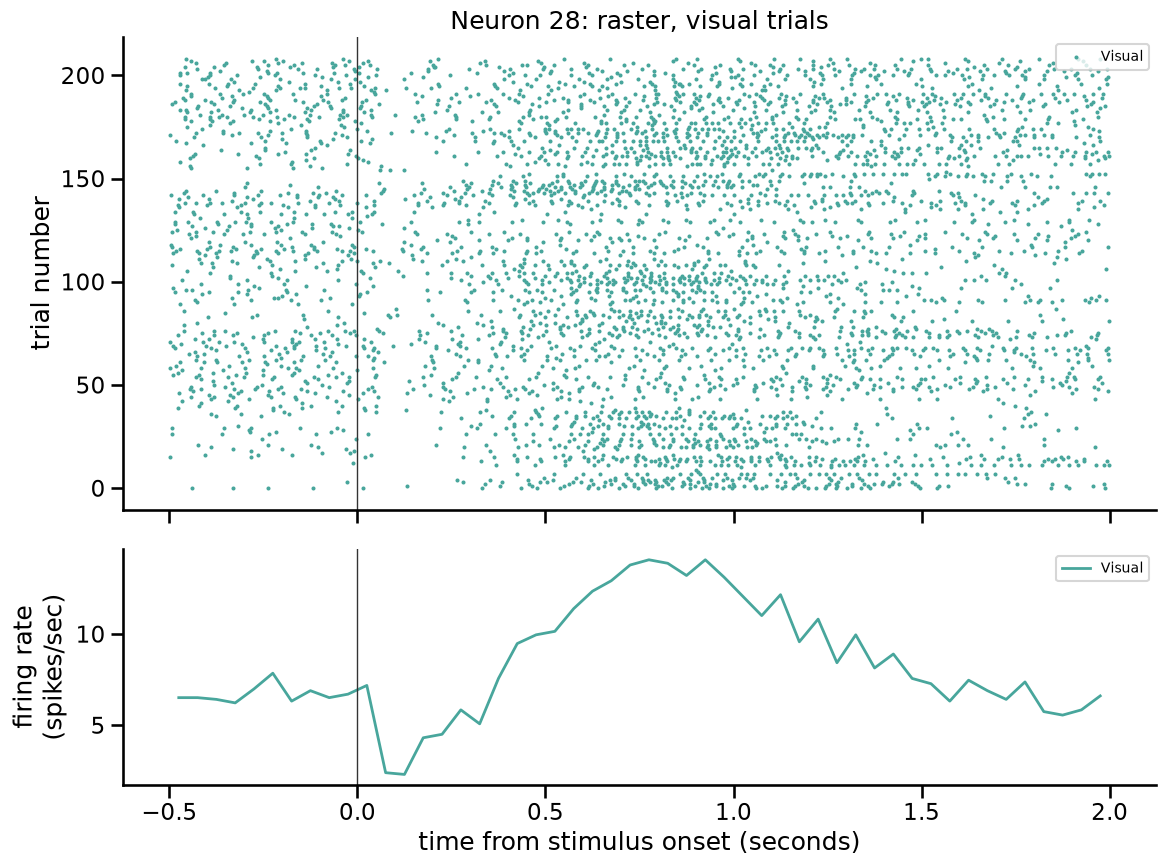

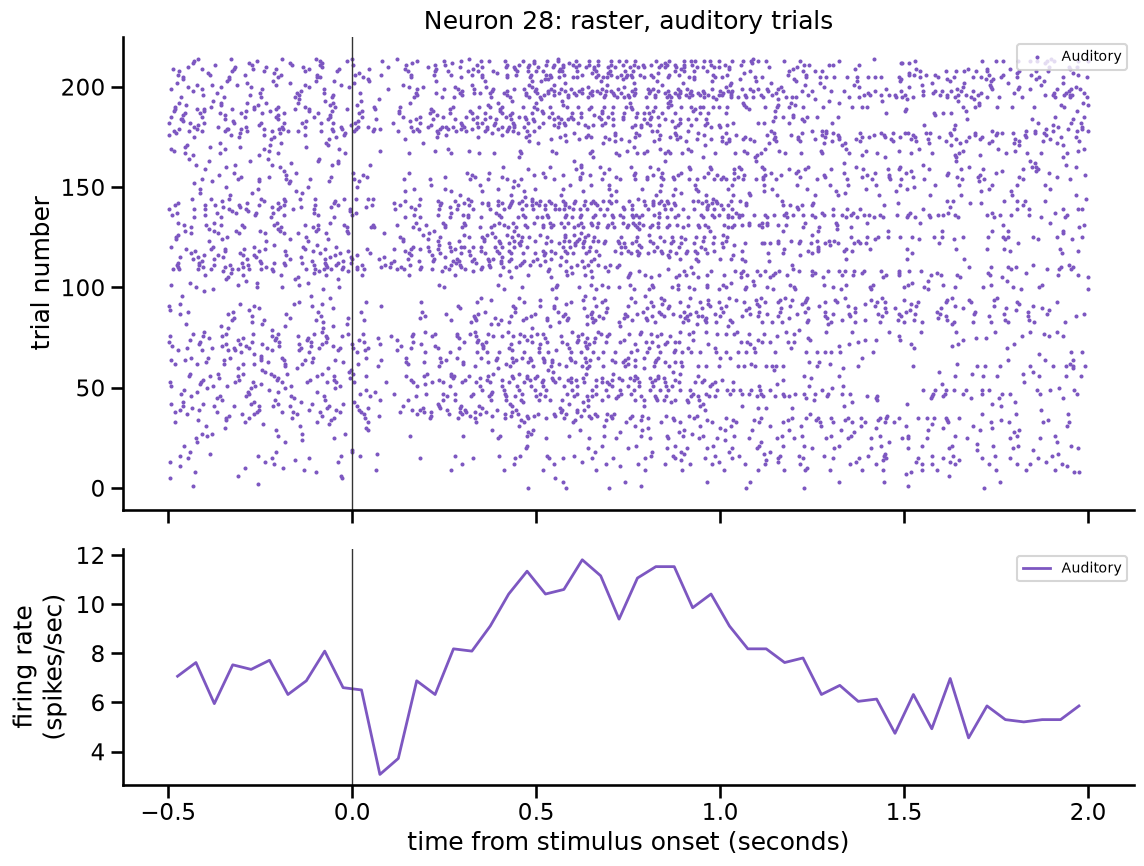

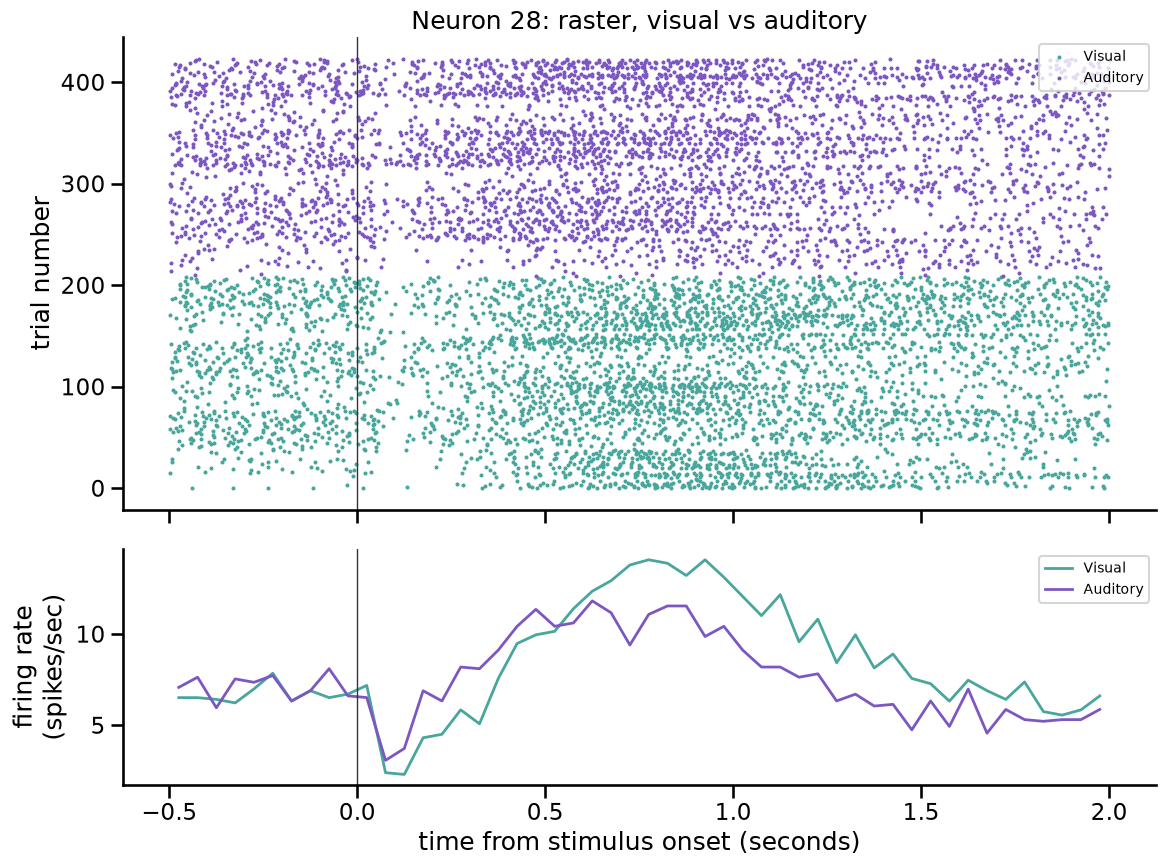

collected spikes 123 hit trials
collected spikes 49 false alarm trials


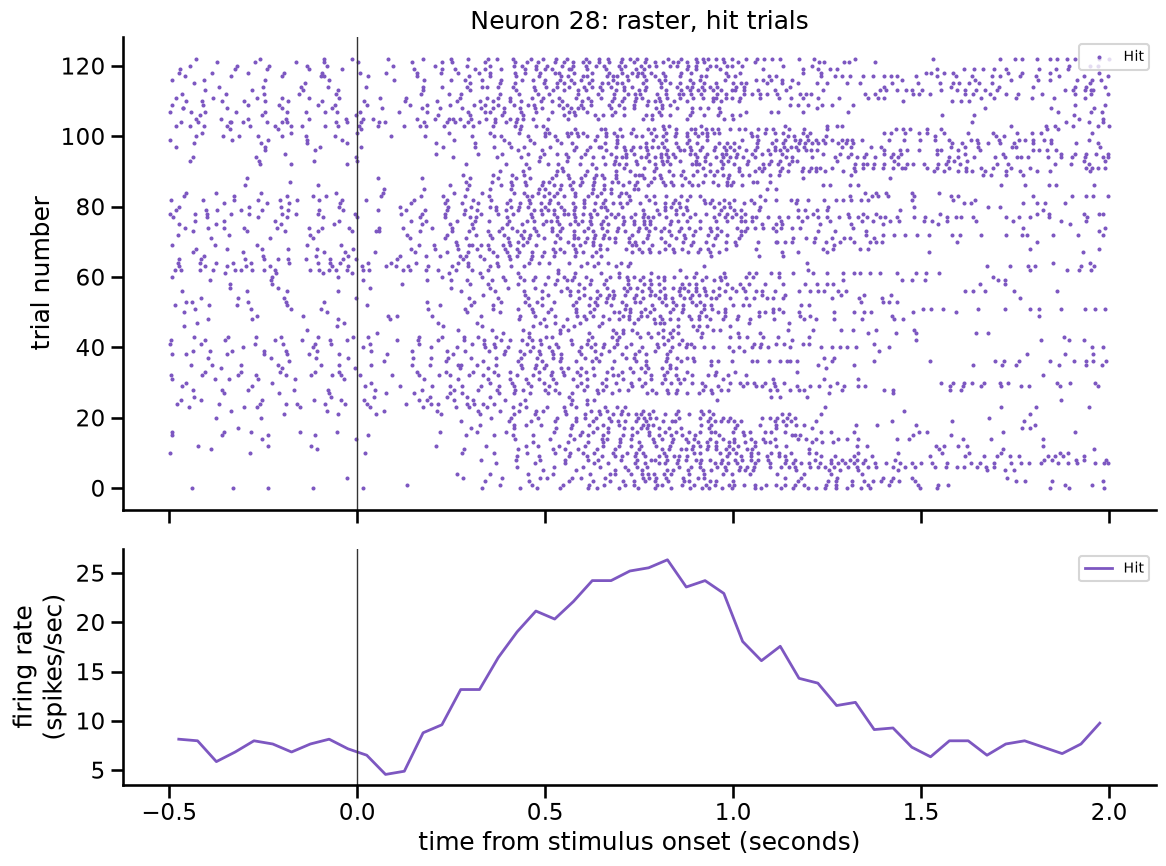

/tmp/ipykernel_17627/1279800692.py:256: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(fa_spike_times, fa_trial_index, s=2, c=fa_color, label='False Alarm')


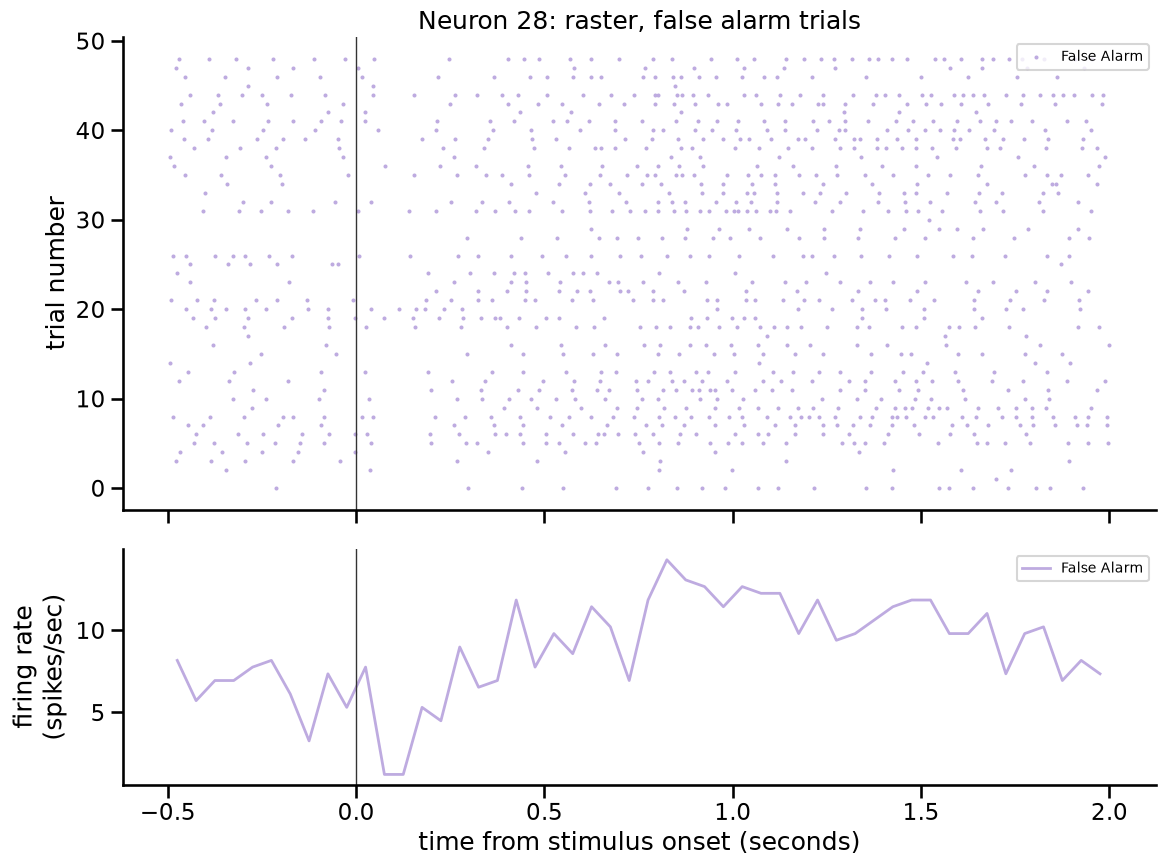

/tmp/ipykernel_17627/1279800692.py:274: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(fa_spike_times, fa_trial_index + len(hit_trials), s=2, c=fa_color, label='False Alarm')


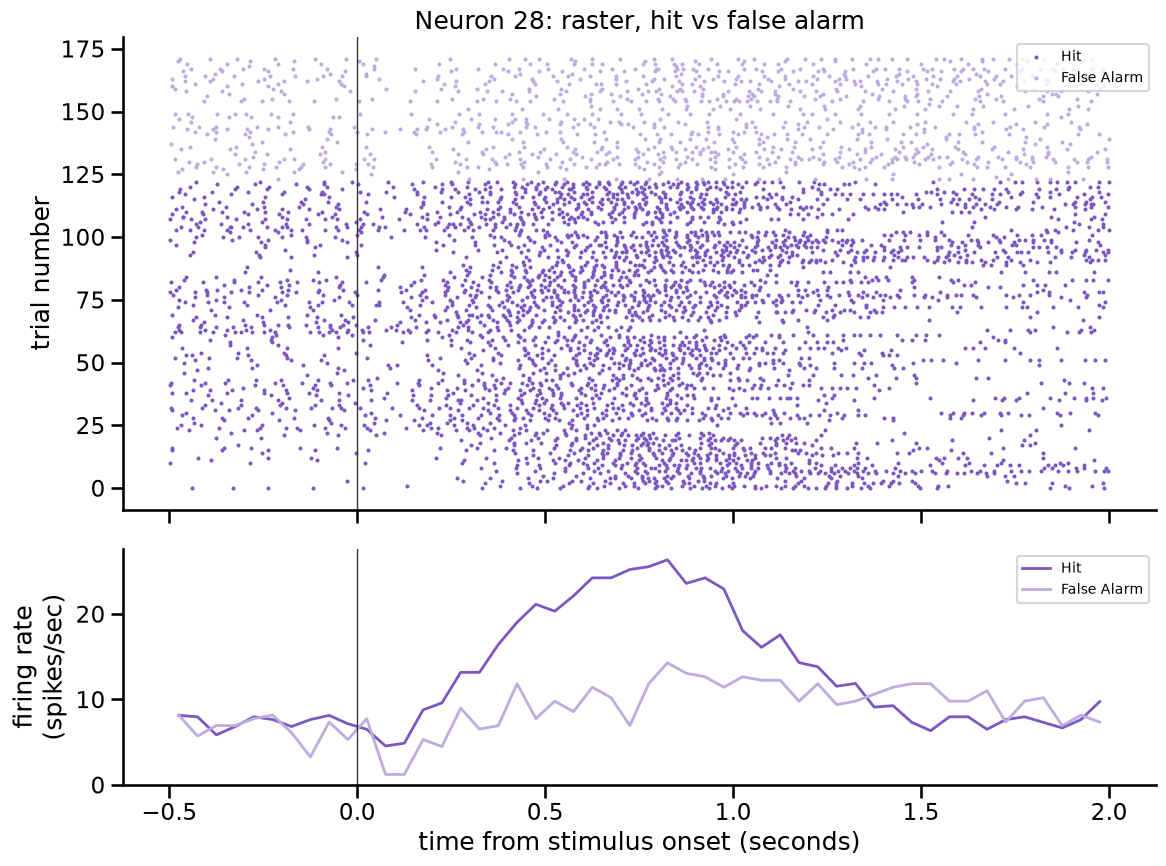

61 trials for Visual (reward time)
65 trials for Auditory (reward time)


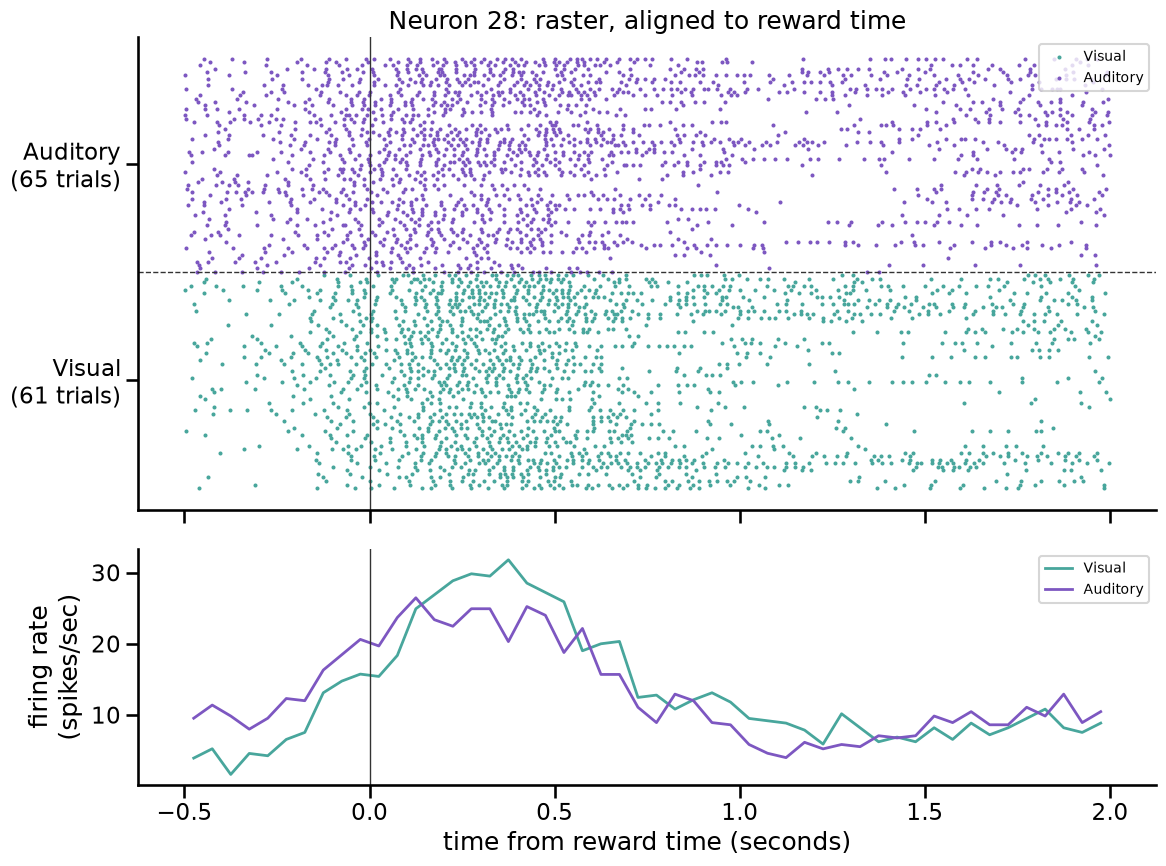

209 trials for Visual (quiescent start)
215 trials for Auditory (quiescent start)


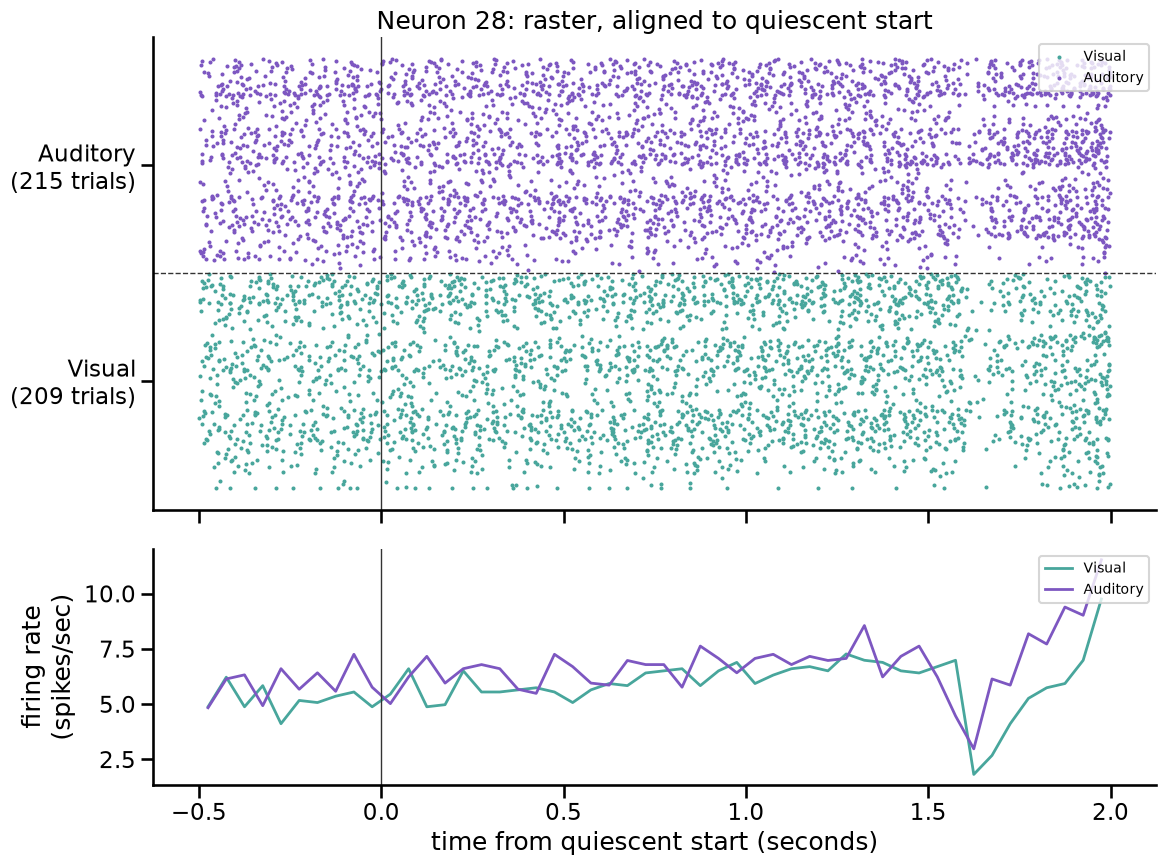

83 trials for Visual (first lick)
86 trials for Auditory (first lick)


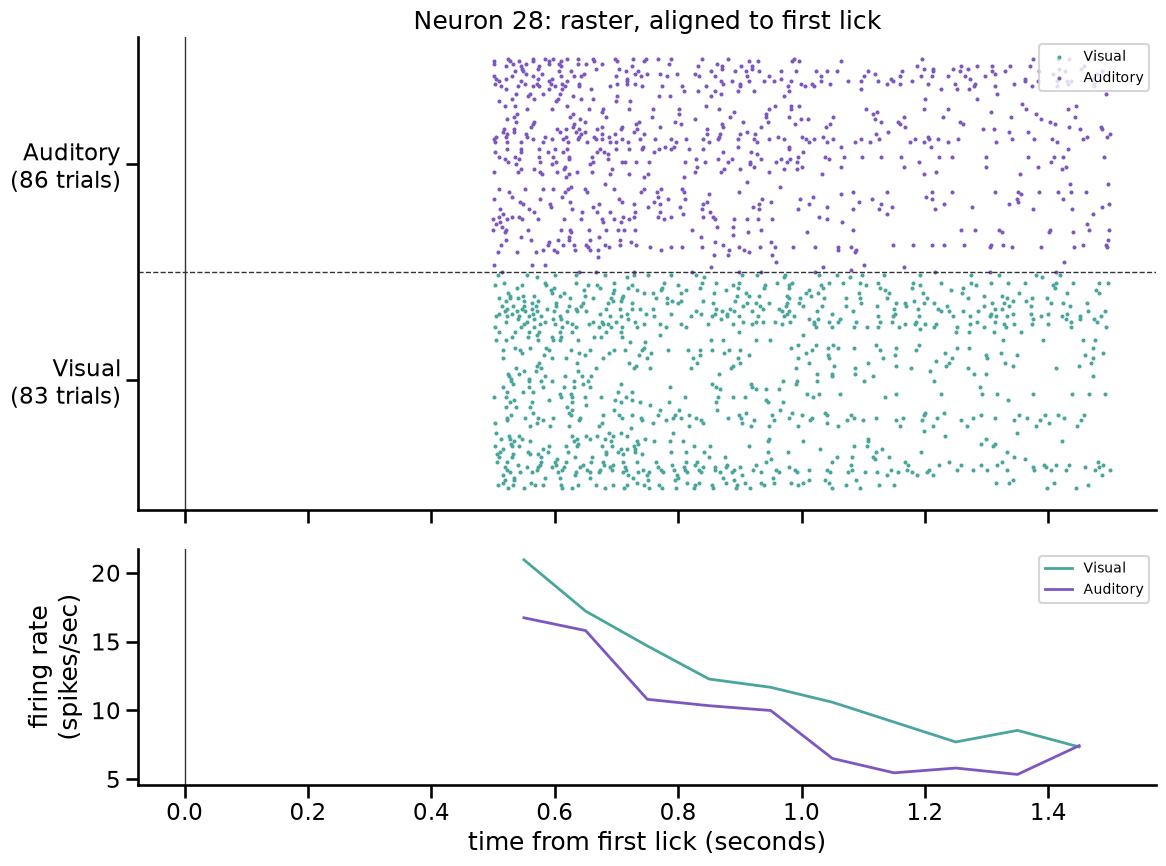

In [ ]:

import glob
import numpy as np
import pandas as pd
import pynwb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_context('talk')
pd.set_option('display.max_columns', None)

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

def lighten_color(hex_color, amount=0.5):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(rgb[i] + (1 - rgb[i]) * amount for i in range(3))

C_PURPLE_LIGHT = lighten_color(C_PURPLE, amount=0.5)


target_neurons = pd.DataFrame([
    {"id": 105,  "structure": "MOs", "cluster_id": 116, "block": "auditory", "mouse_id": 708016},
    {"id": 1593, "structure": "MOs", "cluster_id": 474, "block": "auditory", "mouse_id": 664851},
    {"id": 106,  "structure": "MOs", "cluster_id": 113, "block": "auditory", "mouse_id": 664851},
    {"id": 962,  "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 74,   "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 916,  "structure": "MOs", "cluster_id": 28,  "block": "auditory", "mouse_id": 667252},
    {"id": 1768, "structure": "MOs", "cluster_id": 481, "block": "visual",   "mouse_id": 715710},
    {"id": 2124, "structure": "MOs", "cluster_id": 857, "block": "visual",   "mouse_id": 715710},
    {"id": 23,   "structure": "MOs", "cluster_id": 23,  "block": "visual",   "mouse_id": 667252},
    {"id": 94,   "structure": "MOs", "cluster_id": 105, "block": "visual",   "mouse_id": 708016},
    {"id": 1631, "structure": "MOs", "cluster_id": 39,  "block": "visual",   "mouse_id": 743199},  
    {"id": 2777, "structure": "MOp", "cluster_id": 565, "block": "auditory", "mouse_id": 742903},
    {"id": 2918, "structure": "MOp", "cluster_id": 711, "block": "auditory", "mouse_id": 742903},
    {"id": 841,  "structure": "MOp", "cluster_id": 476, "block": "auditory", "mouse_id": 708016},
    {"id": 2693, "structure": "MOp", "cluster_id": 684, "block": "visual",   "mouse_id": 742903},
    {"id": 586,  "structure": "MOp", "cluster_id": 213, "block": "visual",   "mouse_id": 708016},
    {"id": 325,  "structure": "MOp", "cluster_id": 188, "block": "visual",   "mouse_id": 667252},
])

mouse_to_session = {
    708016: "708016_2024-04-29",
    664851: "664851_2023-11-16",
    667252: "667252_2023-09-28",
    715710: "715710_2024-07-16",
    742903: "742903_2024-10-23",
    743199: "743199_2024-12-05",
}
target_neurons["session_id"] = target_neurons["mouse_id"].map(mouse_to_session)


selected_id = 916
selected = target_neurons[target_neurons.id == selected_id].iloc[0]
print(selected)



data_root = '/root/capsule/data/dynamicrouting_datacube'
session_id = selected.session_id

match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
assert len(match_list) == 1, \
    'expected exactly one match for session %s, found %d' % (session_id, len(match_list))
nwb_path = match_list[0]
print('loading session from: %s' % nwb_path)

session = pynwb.read_nwb(nwb_path)
print('loaded session %s' % session_id)



trials = session.trials.to_dataframe()
print('this session has %d trials' % len(trials))



df = session.units.to_dataframe()
units_table = df.sort_values(by=['firing_rate', 'snr'], ascending=False)


MAX_ISI_VIOLATIONS_RATIO = 0.5
MAX_AMPLITUDE_CUTOFF = 0.1
MIN_PRESENCE_RATIO = 0.95

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

brain_area = selected.structure
this_structure_units_table = good_units[good_units.structure == brain_area]
print('%d good units in %s' % (len(this_structure_units_table), brain_area))


neuron_id = selected.cluster_id
match = this_structure_units_table[this_structure_units_table.cluster_id == neuron_id]
assert len(match) == 1, 'expected 1 match for cluster_id %d, found %d' % (neuron_id, len(match))

spike_times = match.iloc[0].spike_times
print('neuron %d has %d spikes' % (neuron_id, len(spike_times)))


trial_firing_rates = []
for _, trial in trials.iterrows():
    duration = trial.stop_time - trial.start_time
    spikes_in_trial = spike_times[(spike_times >= trial.start_time) & (spike_times < trial.stop_time)]
    rate = len(spikes_in_trial) / duration
    trial_firing_rates.append(rate)
trials["firing_rate"] = trial_firing_rates


trials["firing_rate_hit"] = np.where(trials["is_hit"], trials["firing_rate"], np.nan)
trials["firing_rate_fa"] = np.where(trials["is_false_alarm"], trials["firing_rate"], np.nan)

hit_trials = trials[trials.is_hit]
fa_trials = trials[trials.is_false_alarm]


pre_window = 0.5
post_window = 2.0
bin_size = 0.05
bins = np.arange(-pre_window, post_window + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2

def align_spikes_to_trials(spike_times, trial_subset, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    stim_times = trial_subset["stim_start_time"].values
    for i, stim_time in enumerate(stim_times):
        mask = ((spike_times >= stim_time - pre_window) &
                (spike_times < stim_time + post_window))
        trial_spikes = spike_times[mask] - stim_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)

vis_trials = trials[trials.is_vis_stim]
aud_trials = trials[trials.is_aud_stim]

vis_spike_times, vis_trial_index = align_spikes_to_trials(spike_times, vis_trials, pre_window, post_window)
aud_spike_times, aud_trial_index = align_spikes_to_trials(spike_times, aud_trials, pre_window, post_window)

print('collected spikes %d visual trials' % len(vis_trials))
print('collected spikes %d auditory trials' % len(aud_trials))

vis_color = C_TEAL
aud_color = C_PURPLE

vis_count_array, _ = np.histogram(vis_spike_times, bins=bins)
vis_rate_array = vis_count_array / len(vis_trials) / bin_size

aud_count_array, _ = np.histogram(aud_spike_times, bins=bins)
aud_rate_array = aud_count_array / len(aud_trials) / bin_size

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(vis_spike_times, vis_trial_index, s=2, c=vis_color, label='Visual')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, visual trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, vis_rate_array, c=vis_color, lw=2, label='Visual')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(aud_spike_times, aud_trial_index, s=2, c=aud_color, label='Auditory')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, auditory trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, aud_rate_array, c=aud_color, lw=2, label='Auditory')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(vis_spike_times, vis_trial_index, s=2, c=vis_color, label='Visual')
ax_raster.scatter(aud_spike_times, aud_trial_index + len(vis_trials), s=2, c=aud_color, label='Auditory')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, visual vs auditory' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, vis_rate_array, c=vis_color, lw=2, label='Visual')
ax_trace.plot(bin_centers, aud_rate_array, c=aud_color, lw=2, label='Auditory')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()


hit_spike_times, hit_trial_index = align_spikes_to_trials(spike_times, hit_trials, pre_window, post_window)
fa_spike_times, fa_trial_index = align_spikes_to_trials(spike_times, fa_trials, pre_window, post_window)

print('collected spikes %d hit trials' % len(hit_trials))
print('collected spikes %d false alarm trials' % len(fa_trials))

hit_color = C_PURPLE
fa_color = C_PURPLE_LIGHT

hit_count_array, _ = np.histogram(hit_spike_times, bins=bins)
hit_rate_array = hit_count_array / len(hit_trials) / bin_size

fa_count_array, _ = np.histogram(fa_spike_times, bins=bins)
fa_rate_array = fa_count_array / len(fa_trials) / bin_size

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(hit_spike_times, hit_trial_index, s=2, c=hit_color, label='Hit')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, hit trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(fa_spike_times, fa_trial_index, s=2, c=fa_color, label='False Alarm')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, false alarm trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(hit_spike_times, hit_trial_index, s=2, c=hit_color, label='Hit')
ax_raster.scatter(fa_spike_times, fa_trial_index + len(hit_trials), s=2, c=fa_color, label='False Alarm')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, hit vs false alarm' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()


lane_height = 100

def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    for i, event_time in enumerate(event_times):
        mask = ((spike_times >= event_time - pre_window) &
                (spike_times < event_time + post_window))
        trial_spikes = spike_times[mask] - event_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)

def plot_event_aligned_by_group(spike_times, trial_subset, event_column, event_label, neuron_id,
                                 group_defs, pre_window, post_window, bin_size):
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2

    fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    yticks, yticklabels = [], []

    for lane_number, (group_label, (group_mask, color)) in enumerate(group_defs.items()):
        group_trials = trial_subset[trial_subset[group_mask]] if isinstance(group_mask, str) else trial_subset[group_mask]
        event_times = group_trials[event_column].dropna().values
        print('%d trials for %s (%s)' % (len(event_times), group_label, event_label))
        if len(event_times) == 0:
            continue

        triggered_spike_times, triggered_trial_index = align_spikes_to_events(spike_times, event_times, pre_window, post_window)
        count_array, _ = np.histogram(triggered_spike_times, bins=bins)
        rate_array = count_array / len(event_times) / bin_size
        trial_index_scaled = (triggered_trial_index / len(event_times)) * lane_height + (lane_number * lane_height)

        ax_raster.scatter(triggered_spike_times, trial_index_scaled, s=2, c=color, label=group_label)
        ax_trace.plot(bin_centers, rate_array, c=color, lw=2, label=group_label)
        yticks.append(lane_number * lane_height + lane_height / 2)
        yticklabels.append('%s\n(%d trials)' % (group_label, len(event_times)))
        if lane_number < len(group_defs) - 1:
            ax_raster.axhline((lane_number + 1) * lane_height, c=C_GREY, lw=1, ls='--')

    ax_raster.axvline(0, c=C_GREY, lw=1)
    ax_raster.set_yticks(yticks)
    ax_raster.set_yticklabels(yticklabels)
    ax_raster.set_title('Neuron %d: raster, aligned to %s' % (neuron_id, event_label))
    ax_raster.legend(loc='upper right', fontsize=10)
    ax_trace.axvline(0, c=C_GREY, lw=1)
    ax_trace.set_xlabel('time from %s (seconds)' % event_label)
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=10)
    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()
    plt.show()

group_defs = {
    'Visual':   ('is_vis_stim', C_TEAL),
    'Auditory': ('is_aud_stim', C_PURPLE),
}

reward_trials = trials[trials["reward_time"].notna()]
plot_event_aligned_by_group(spike_times, reward_trials, "reward_time", "reward time", neuron_id,
                             group_defs, pre_window=0.5, post_window=2.0, bin_size=0.05)

plot_event_aligned_by_group(spike_times, trials, "quiescent_start_time", "quiescent start", neuron_id,
                             group_defs, pre_window=0.5, post_window=2.0, bin_size=0.05)

lick_trials = trials[trials["is_response"] & trials["response_time"].notna()]
plot_event_aligned_by_group(spike_times, lick_trials, "response_time", "first lick", neuron_id,
                             group_defs, pre_window=-0.5, post_window=1.5, bin_size=0.1)

In [3]:
print('total trials:', len(trials))
print('hit trials:', len(hit_trials))
print('false alarm trials:', len(fa_trials))

total trials: 486
hit trials: 123
false alarm trials: 49


In [4]:
print('collected spikes %d hit trials' % len(hit_trials))
print('collected spikes %d false alarm trials' % len(fa_trials))


collected spikes 123 hit trials
collected spikes 49 false alarm trials


In [1]:
# ==== CELL 11 (updated): hit vs false alarm -- alone, alone, combined (with equal-height lanes) ====
hit_spike_times, hit_trial_index = align_spikes_to_trials(spike_times, hit_trials, pre_window, post_window)
fa_spike_times, fa_trial_index = align_spikes_to_trials(spike_times, fa_trials, pre_window, post_window)

print('collected spikes %d hit trials' % len(hit_trials))
print('collected spikes %d false alarm trials' % len(fa_trials))

hit_color = C_PURPLE
fa_color = C_PURPLE_LIGHT

hit_count_array, _ = np.histogram(hit_spike_times, bins=bins)
hit_rate_array = hit_count_array / len(hit_trials) / bin_size

fa_count_array, _ = np.histogram(fa_spike_times, bins=bins)
fa_rate_array = fa_count_array / len(fa_trials) / bin_size

# -- hits alone (unchanged) --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(hit_spike_times, hit_trial_index, s=2, c=hit_color, label='Hit')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, hit trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

# -- false alarms alone (unchanged) --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(fa_spike_times, fa_trial_index, s=2, c=fa_color, label='False Alarm')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, false alarm trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

# -- combined: hit vs false alarm, EQUAL-HEIGHT scaled lanes, overlaid trace --
lane_height = 100
hit_trial_index_scaled = (hit_trial_index / len(hit_trials)) * lane_height
fa_trial_index_scaled = (fa_trial_index / len(fa_trials)) * lane_height + lane_height

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(hit_spike_times, hit_trial_index_scaled, s=2, c=hit_color, label='Hit')
ax_raster.scatter(fa_spike_times, fa_trial_index_scaled, s=2, c=fa_color, label='False Alarm')
ax_raster.axhline(lane_height, c=C_GREY, lw=1, ls='--')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_yticks([lane_height / 2, lane_height + lane_height / 2])
ax_raster.set_yticklabels(['Hit\n(%d trials)' % len(hit_trials), 'False Alarm\n(%d trials)' % len(fa_trials)])
ax_raster.set_title('Neuron %d: raster, hit vs false alarm' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

NameError: name 'align_spikes_to_trials' is not defined

id                          916
structure                   MOs
cluster_id                   28
block                  auditory
mouse_id                 667252
session_id    667252_2023-09-28
Name: 5, dtype: object
loading session from: /root/capsule/data/dynamicrouting_datacube/ecephys_667252_2023-09-28_15-00-38_nwb_2026-08-04_15-21-37/667252_2023-09-28.nwb.zarr


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(


loaded session 667252_2023-09-28
this session has 486 trials
524 of 1181 units passed quality control
190 good units in MOs
neuron 28 has 35191 spikes
collected spikes 209 visual trials
collected spikes 215 auditory trials


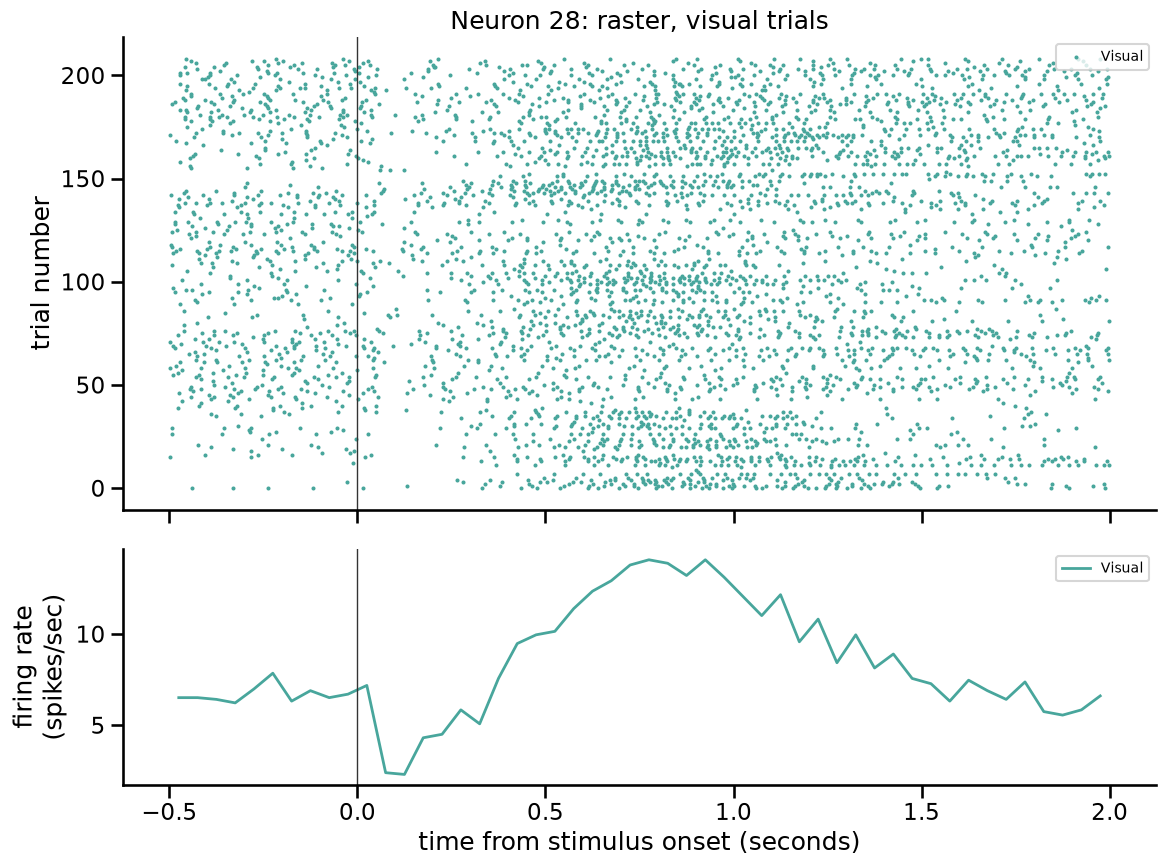

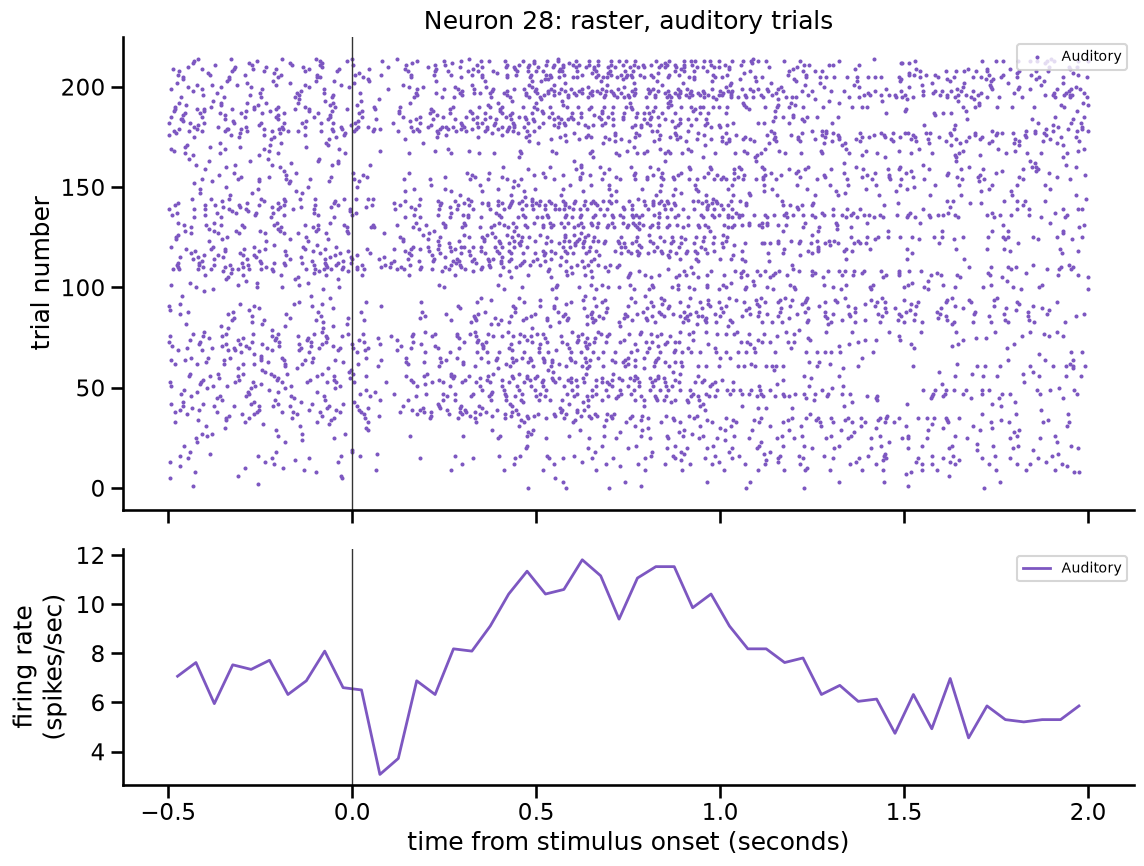

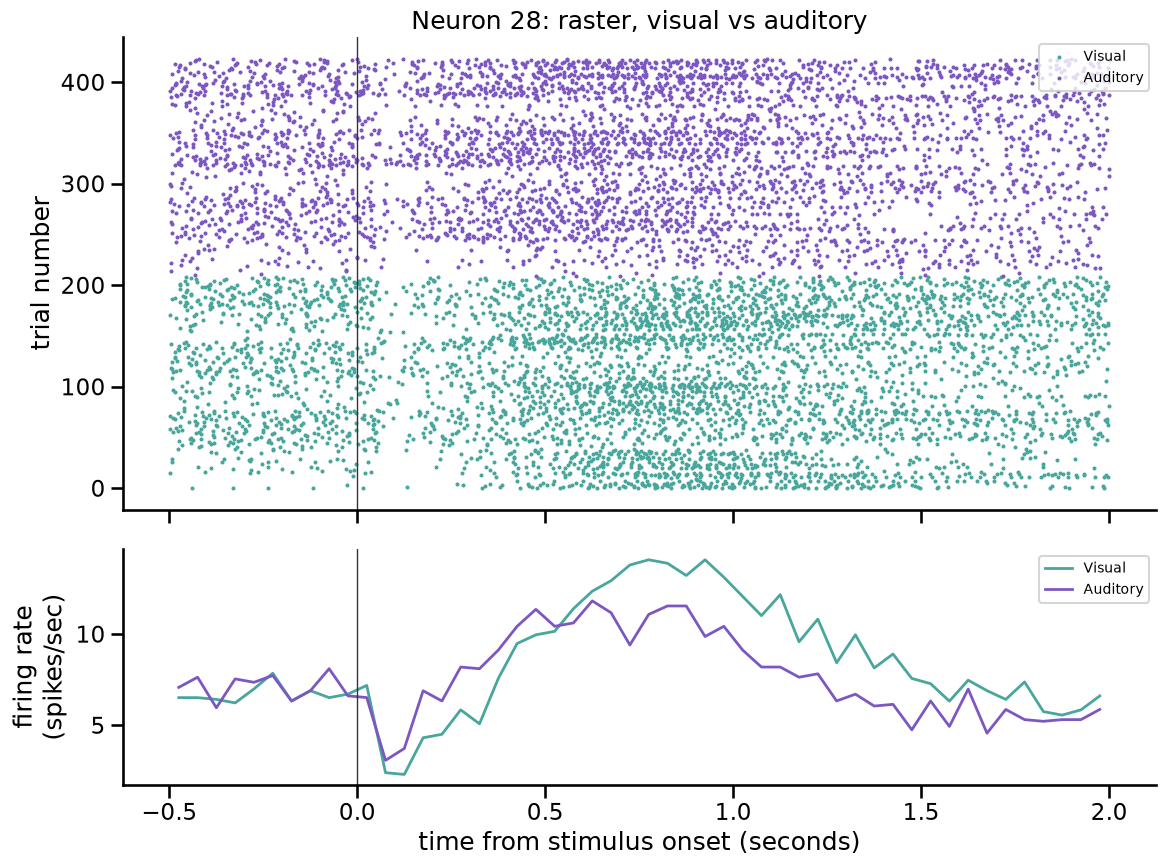

collected spikes 123 hit trials
collected spikes 49 false alarm trials


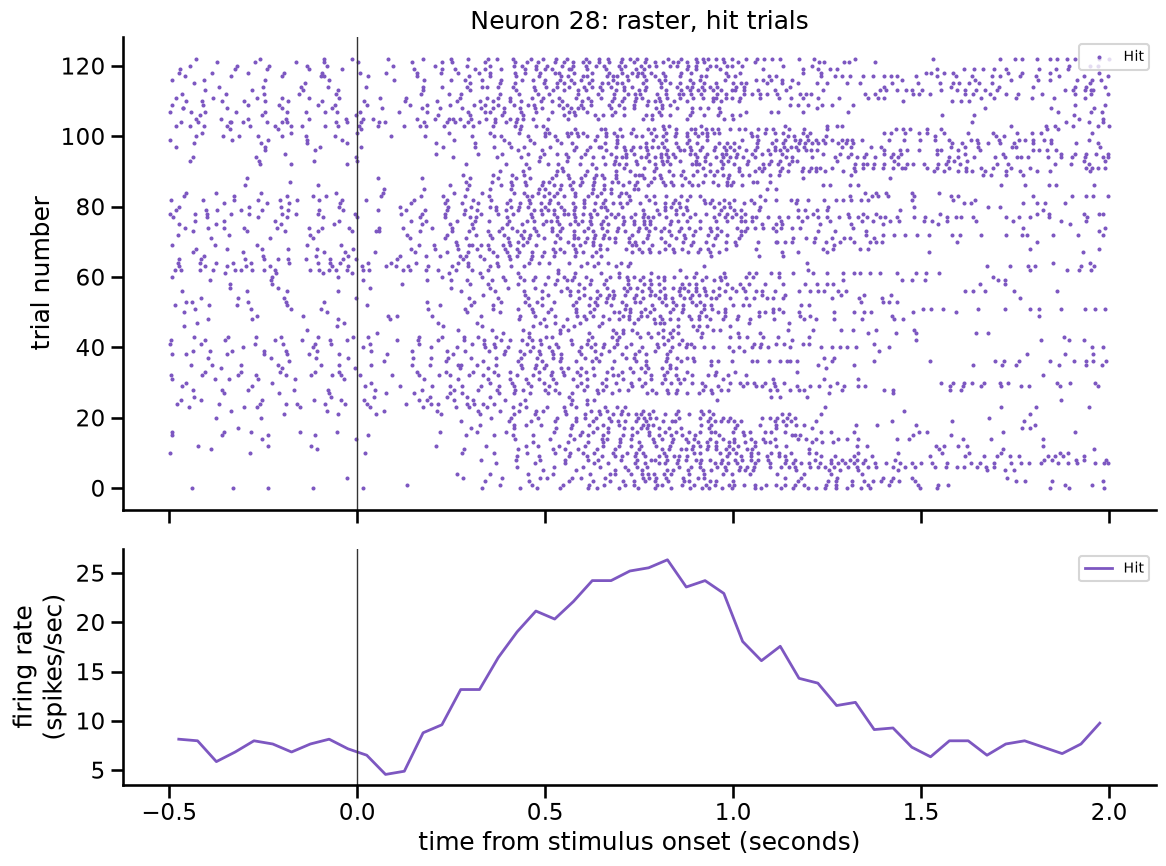

/tmp/ipykernel_34991/3270878276.py:258: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(fa_spike_times, fa_trial_index, s=2, c=fa_color, label='False Alarm')


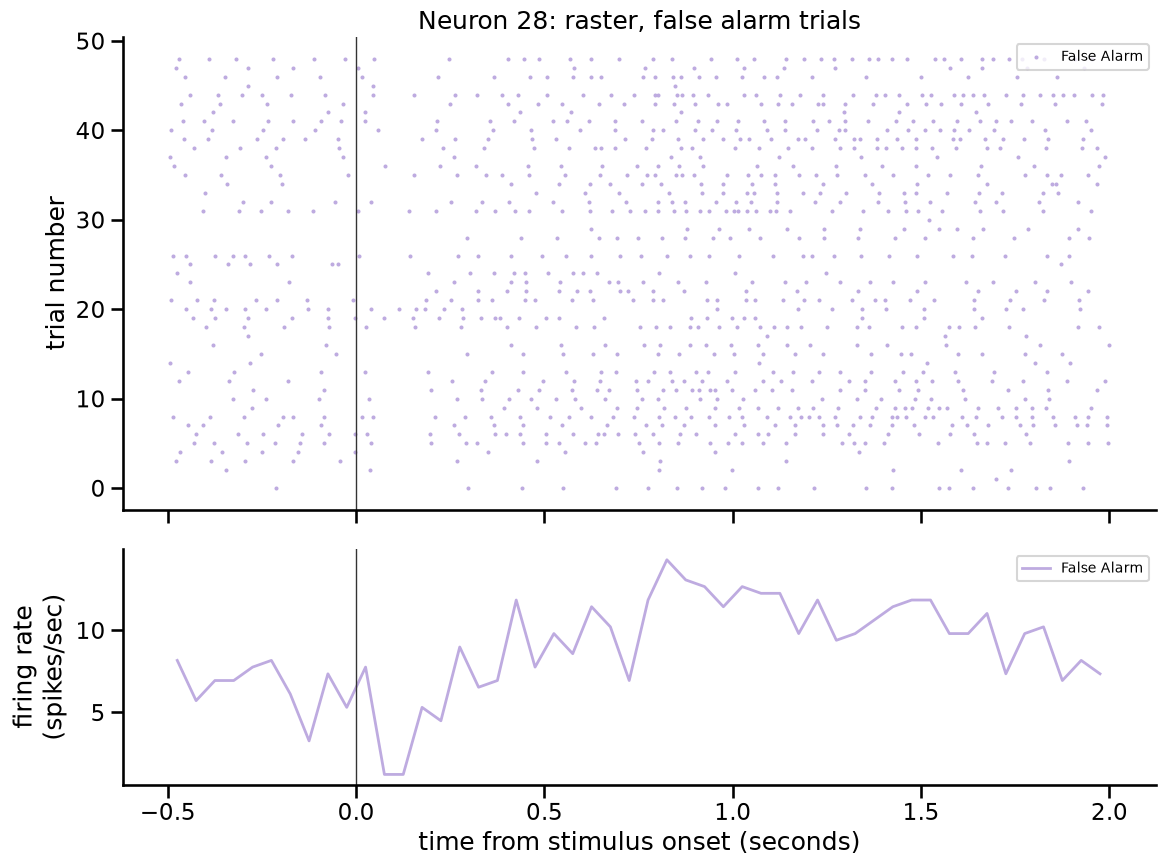

/tmp/ipykernel_34991/3270878276.py:280: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(fa_spike_times, fa_trial_index_scaled, s=2, c=fa_color, label='False Alarm')


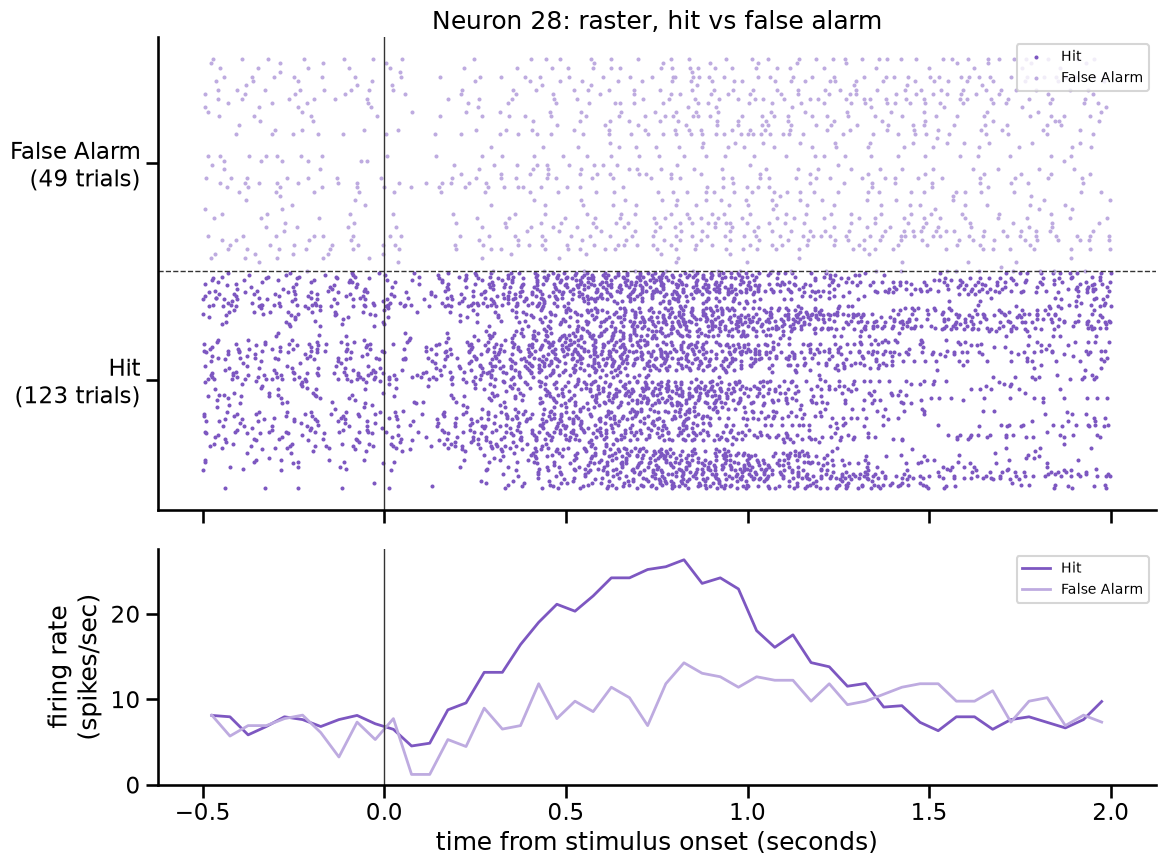

61 trials for Visual (reward time)
65 trials for Auditory (reward time)


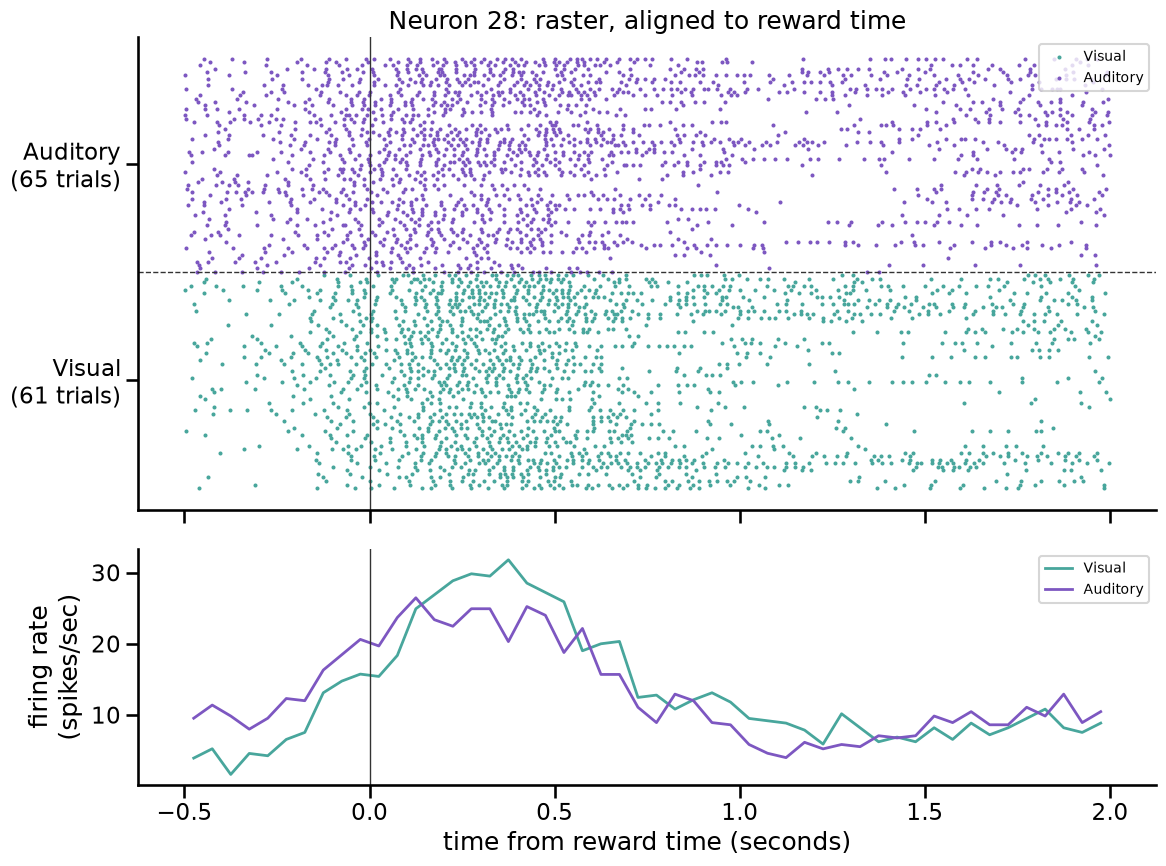

209 trials for Visual (quiescent start)
215 trials for Auditory (quiescent start)


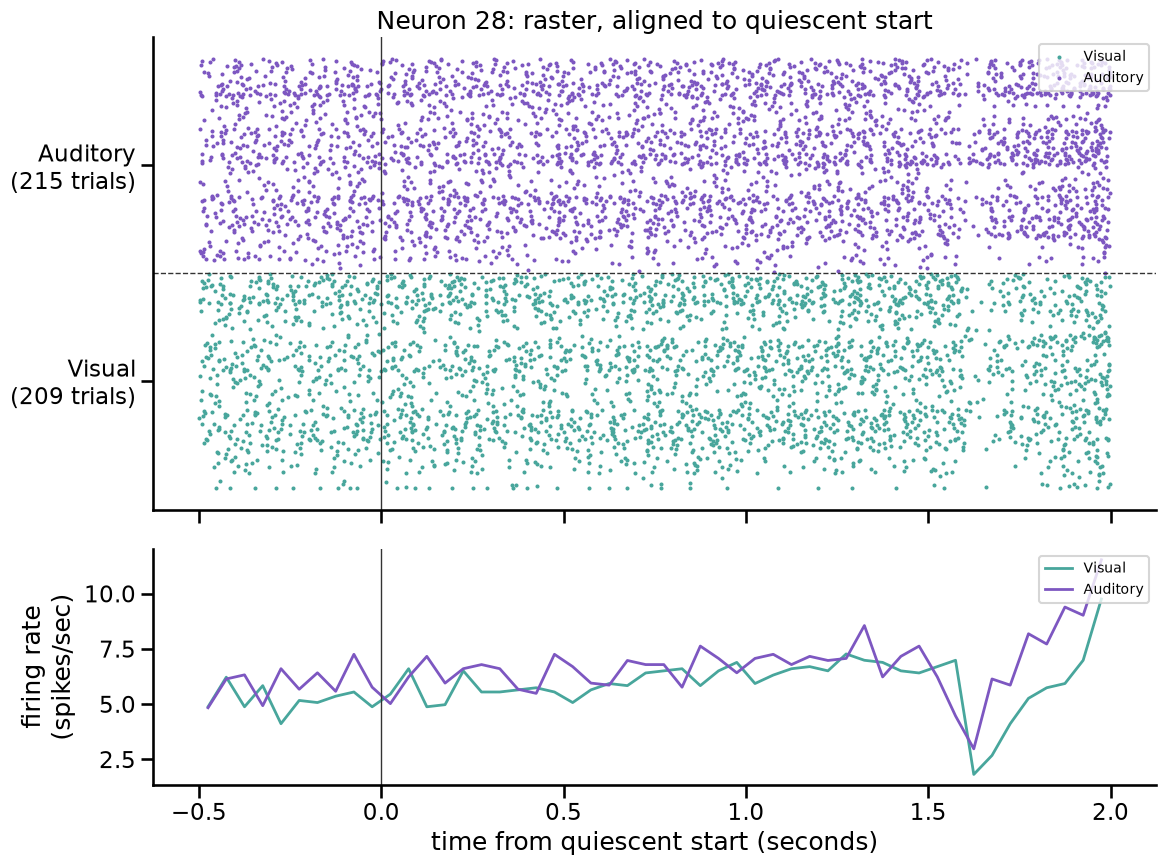

83 trials for Visual (first lick)
86 trials for Auditory (first lick)


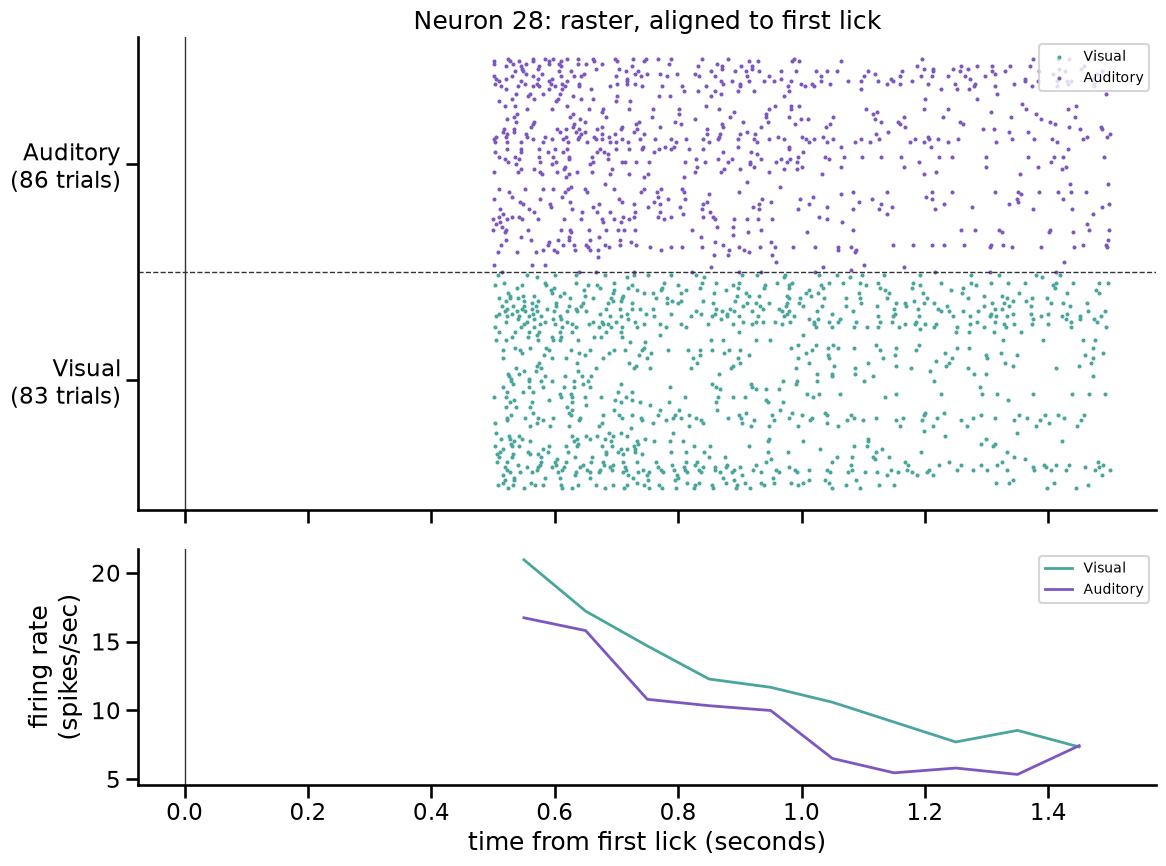

In [2]:
# ==== CELL 0: imports & settings ====
import glob
import numpy as np
import pandas as pd
import pynwb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_context('talk')
pd.set_option('display.max_columns', None)

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

def lighten_color(hex_color, amount=0.5):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(rgb[i] + (1 - rgb[i]) * amount for i in range(3))

C_PURPLE_LIGHT = lighten_color(C_PURPLE, amount=0.5)


# ==== CELL 1: neuron table + mouse -> session lookup ====
target_neurons = pd.DataFrame([
    {"id": 105,  "structure": "MOs", "cluster_id": 116, "block": "auditory", "mouse_id": 708016},
    {"id": 1593, "structure": "MOs", "cluster_id": 474, "block": "auditory", "mouse_id": 664851},
    {"id": 106,  "structure": "MOs", "cluster_id": 113, "block": "auditory", "mouse_id": 664851},
    {"id": 962,  "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 74,   "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 916,  "structure": "MOs", "cluster_id": 28,  "block": "auditory", "mouse_id": 667252},
    {"id": 1768, "structure": "MOs", "cluster_id": 481, "block": "visual",   "mouse_id": 715710},
    {"id": 2124, "structure": "MOs", "cluster_id": 857, "block": "visual",   "mouse_id": 715710},
    {"id": 23,   "structure": "MOs", "cluster_id": 23,  "block": "visual",   "mouse_id": 667252},
    {"id": 94,   "structure": "MOs", "cluster_id": 105, "block": "visual",   "mouse_id": 708016},
    {"id": 1631, "structure": "MOs", "cluster_id": 39,  "block": "visual",   "mouse_id": 743199},  # table said 723199 -- confirm
    {"id": 2777, "structure": "MOp", "cluster_id": 565, "block": "auditory", "mouse_id": 742903},
    {"id": 2918, "structure": "MOp", "cluster_id": 711, "block": "auditory", "mouse_id": 742903},
    {"id": 841,  "structure": "MOp", "cluster_id": 476, "block": "auditory", "mouse_id": 708016},
    {"id": 2693, "structure": "MOp", "cluster_id": 684, "block": "visual",   "mouse_id": 742903},
    {"id": 586,  "structure": "MOp", "cluster_id": 213, "block": "visual",   "mouse_id": 708016},
    {"id": 325,  "structure": "MOp", "cluster_id": 188, "block": "visual",   "mouse_id": 667252},
])

mouse_to_session = {
    708016: "708016_2024-04-29",
    664851: "664851_2023-11-16",
    667252: "667252_2023-09-28",
    715710: "715710_2024-07-16",
    742903: "742903_2024-10-23",
    743199: "743199_2024-12-05",
}
target_neurons["session_id"] = target_neurons["mouse_id"].map(mouse_to_session)

# ---- pick which neuron you want to plot -- just change this one line ----
selected_id = 916
selected = target_neurons[target_neurons.id == selected_id].iloc[0]
print(selected)


# ==== CELL 2: load that neuron's session ====
data_root = '/root/capsule/data/dynamicrouting_datacube'
session_id = selected.session_id

match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
assert len(match_list) == 1, \
    'expected exactly one match for session %s, found %d' % (session_id, len(match_list))
nwb_path = match_list[0]
print('loading session from: %s' % nwb_path)

session = pynwb.read_nwb(nwb_path)
print('loaded session %s' % session_id)


# ==== CELL 3: trials ====
trials = session.trials.to_dataframe()
print('this session has %d trials' % len(trials))


# ==== CELL 4: units table ====
df = session.units.to_dataframe()
units_table = df.sort_values(by=['firing_rate', 'snr'], ascending=False)


# ==== CELL 5: QC + structure filter ====
MAX_ISI_VIOLATIONS_RATIO = 0.5
MAX_AMPLITUDE_CUTOFF = 0.1
MIN_PRESENCE_RATIO = 0.95

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

brain_area = selected.structure
this_structure_units_table = good_units[good_units.structure == brain_area]
print('%d good units in %s' % (len(this_structure_units_table), brain_area))


# ==== CELL 6: pull spike_times for the SPECIFIC neuron by cluster_id ====
neuron_id = selected.cluster_id
match = this_structure_units_table[this_structure_units_table.cluster_id == neuron_id]
assert len(match) == 1, 'expected 1 match for cluster_id %d, found %d' % (neuron_id, len(match))

spike_times = match.iloc[0].spike_times
print('neuron %d has %d spikes' % (neuron_id, len(spike_times)))


# ==== CELL 7: firing rate per trial ====
trial_firing_rates = []
for _, trial in trials.iterrows():
    duration = trial.stop_time - trial.start_time
    spikes_in_trial = spike_times[(spike_times >= trial.start_time) & (spike_times < trial.stop_time)]
    rate = len(spikes_in_trial) / duration
    trial_firing_rates.append(rate)
trials["firing_rate"] = trial_firing_rates


# ==== CELL 8: hit/FA columns and subsets ====
trials["firing_rate_hit"] = np.where(trials["is_hit"], trials["firing_rate"], np.nan)
trials["firing_rate_fa"] = np.where(trials["is_false_alarm"], trials["firing_rate"], np.nan)

hit_trials = trials[trials.is_hit]
fa_trials = trials[trials.is_false_alarm]


# ==== CELL 9: shared alignment window + function (used by cells 10, 11) ====
pre_window = 0.5
post_window = 2.0
bin_size = 0.05
bins = np.arange(-pre_window, post_window + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2

def align_spikes_to_trials(spike_times, trial_subset, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    stim_times = trial_subset["stim_start_time"].values
    for i, stim_time in enumerate(stim_times):
        mask = ((spike_times >= stim_time - pre_window) &
                (spike_times < stim_time + post_window))
        trial_spikes = spike_times[mask] - stim_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)


# ==== CELL 10: visual vs auditory -- alone, alone, combined ====
vis_trials = trials[trials.is_vis_stim]
aud_trials = trials[trials.is_aud_stim]

vis_spike_times, vis_trial_index = align_spikes_to_trials(spike_times, vis_trials, pre_window, post_window)
aud_spike_times, aud_trial_index = align_spikes_to_trials(spike_times, aud_trials, pre_window, post_window)

print('collected spikes %d visual trials' % len(vis_trials))
print('collected spikes %d auditory trials' % len(aud_trials))

vis_color = C_TEAL
aud_color = C_PURPLE

vis_count_array, _ = np.histogram(vis_spike_times, bins=bins)
vis_rate_array = vis_count_array / len(vis_trials) / bin_size

aud_count_array, _ = np.histogram(aud_spike_times, bins=bins)
aud_rate_array = aud_count_array / len(aud_trials) / bin_size

# -- visual alone --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(vis_spike_times, vis_trial_index, s=2, c=vis_color, label='Visual')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, visual trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, vis_rate_array, c=vis_color, lw=2, label='Visual')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

# -- auditory alone --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(aud_spike_times, aud_trial_index, s=2, c=aud_color, label='Auditory')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, auditory trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, aud_rate_array, c=aud_color, lw=2, label='Auditory')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

# -- combined: visual vs auditory --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(vis_spike_times, vis_trial_index, s=2, c=vis_color, label='Visual')
ax_raster.scatter(aud_spike_times, aud_trial_index + len(vis_trials), s=2, c=aud_color, label='Auditory')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, visual vs auditory' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, vis_rate_array, c=vis_color, lw=2, label='Visual')
ax_trace.plot(bin_centers, aud_rate_array, c=aud_color, lw=2, label='Auditory')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()


# ==== CELL 11: hit vs false alarm -- alone, alone, combined (equal-height lanes) ====
hit_spike_times, hit_trial_index = align_spikes_to_trials(spike_times, hit_trials, pre_window, post_window)
fa_spike_times, fa_trial_index = align_spikes_to_trials(spike_times, fa_trials, pre_window, post_window)

print('collected spikes %d hit trials' % len(hit_trials))
print('collected spikes %d false alarm trials' % len(fa_trials))

hit_color = C_PURPLE
fa_color = C_PURPLE_LIGHT

hit_count_array, _ = np.histogram(hit_spike_times, bins=bins)
hit_rate_array = hit_count_array / len(hit_trials) / bin_size

fa_count_array, _ = np.histogram(fa_spike_times, bins=bins)
fa_rate_array = fa_count_array / len(fa_trials) / bin_size

# -- hits alone --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(hit_spike_times, hit_trial_index, s=2, c=hit_color, label='Hit')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, hit trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

# -- false alarms alone --
fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(fa_spike_times, fa_trial_index, s=2, c=fa_color, label='False Alarm')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_ylabel('trial number')
ax_raster.set_title('Neuron %d: raster, false alarm trials' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()

# -- combined: hit vs false alarm, equal-height scaled lanes --
lane_height = 100
hit_trial_index_scaled = (hit_trial_index / len(hit_trials)) * lane_height
fa_trial_index_scaled = (fa_trial_index / len(fa_trials)) * lane_height + lane_height

fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax_raster.scatter(hit_spike_times, hit_trial_index_scaled, s=2, c=hit_color, label='Hit')
ax_raster.scatter(fa_spike_times, fa_trial_index_scaled, s=2, c=fa_color, label='False Alarm')
ax_raster.axhline(lane_height, c=C_GREY, lw=1, ls='--')
ax_raster.axvline(0, c=C_GREY, lw=1)
ax_raster.set_yticks([lane_height / 2, lane_height + lane_height / 2])
ax_raster.set_yticklabels(['Hit\n(%d trials)' % len(hit_trials), 'False Alarm\n(%d trials)' % len(fa_trials)])
ax_raster.set_title('Neuron %d: raster, hit vs false alarm' % neuron_id)
ax_raster.legend(loc='upper right', fontsize=10)
ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
ax_trace.axvline(0, c=C_GREY, lw=1)
ax_trace.set_xlabel('time from stimulus onset (seconds)')
ax_trace.set_ylabel('firing rate\n(spikes/sec)')
ax_trace.legend(loc='upper right', fontsize=10)
for single_ax in [ax_raster, ax_trace]:
    sns.despine(ax=single_ax)
fig.tight_layout()
plt.show()


# ==== CELL 12: reward / quiescent / lick, split by visual vs auditory ====
def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    for i, event_time in enumerate(event_times):
        mask = ((spike_times >= event_time - pre_window) &
                (spike_times < event_time + post_window))
        trial_spikes = spike_times[mask] - event_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)

def plot_event_aligned_by_group(spike_times, trial_subset, event_column, event_label, neuron_id,
                                 group_defs, pre_window, post_window, bin_size):
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2
    lane_height = 100

    fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    yticks, yticklabels = [], []

    for lane_number, (group_label, (group_mask, color)) in enumerate(group_defs.items()):
        group_trials = trial_subset[trial_subset[group_mask]] if isinstance(group_mask, str) else trial_subset[group_mask]
        event_times = group_trials[event_column].dropna().values
        print('%d trials for %s (%s)' % (len(event_times), group_label, event_label))
        if len(event_times) == 0:
            continue

        triggered_spike_times, triggered_trial_index = align_spikes_to_events(spike_times, event_times, pre_window, post_window)
        count_array, _ = np.histogram(triggered_spike_times, bins=bins)
        rate_array = count_array / len(event_times) / bin_size
        trial_index_scaled = (triggered_trial_index / len(event_times)) * lane_height + (lane_number * lane_height)

        ax_raster.scatter(triggered_spike_times, trial_index_scaled, s=2, c=color, label=group_label)
        ax_trace.plot(bin_centers, rate_array, c=color, lw=2, label=group_label)
        yticks.append(lane_number * lane_height + lane_height / 2)
        yticklabels.append('%s\n(%d trials)' % (group_label, len(event_times)))
        if lane_number < len(group_defs) - 1:
            ax_raster.axhline((lane_number + 1) * lane_height, c=C_GREY, lw=1, ls='--')

    ax_raster.axvline(0, c=C_GREY, lw=1)
    ax_raster.set_yticks(yticks)
    ax_raster.set_yticklabels(yticklabels)
    ax_raster.set_title('Neuron %d: raster, aligned to %s' % (neuron_id, event_label))
    ax_raster.legend(loc='upper right', fontsize=10)
    ax_trace.axvline(0, c=C_GREY, lw=1)
    ax_trace.set_xlabel('time from %s (seconds)' % event_label)
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=10)
    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()
    plt.show()

group_defs = {
    'Visual':   ('is_vis_stim', C_TEAL),
    'Auditory': ('is_aud_stim', C_PURPLE),
}

reward_trials = trials[trials["reward_time"].notna()]
plot_event_aligned_by_group(spike_times, reward_trials, "reward_time", "reward time", neuron_id,
                             group_defs, pre_window=0.5, post_window=2.0, bin_size=0.05)

plot_event_aligned_by_group(spike_times, trials, "quiescent_start_time", "quiescent start", neuron_id,
                             group_defs, pre_window=0.5, post_window=2.0, bin_size=0.05)

lick_trials = trials[trials["is_response"] & trials["response_time"].notna()]
plot_event_aligned_by_group(spike_times, lick_trials, "response_time", "first lick", neuron_id,
                             group_defs, pre_window=-0.5, post_window=1.5, bin_size=0.1)

Visual: 60 hit trials, 23 false alarm trials


/tmp/ipykernel_34991/3543894462.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(fa_spike_times, fa_trial_index_scaled, s=2, c=fa_color, label='False Alarm')


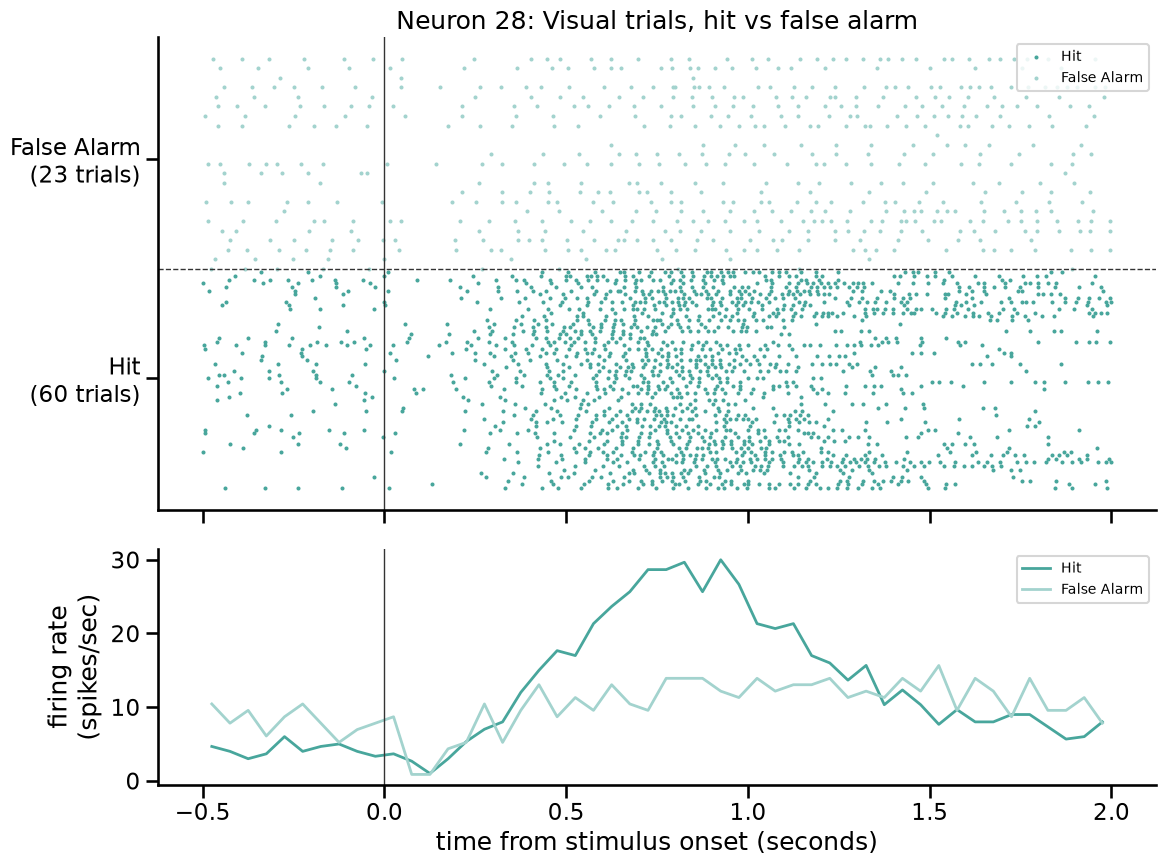

Auditory: 63 hit trials, 26 false alarm trials


/tmp/ipykernel_34991/3543894462.py:28: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(fa_spike_times, fa_trial_index_scaled, s=2, c=fa_color, label='False Alarm')


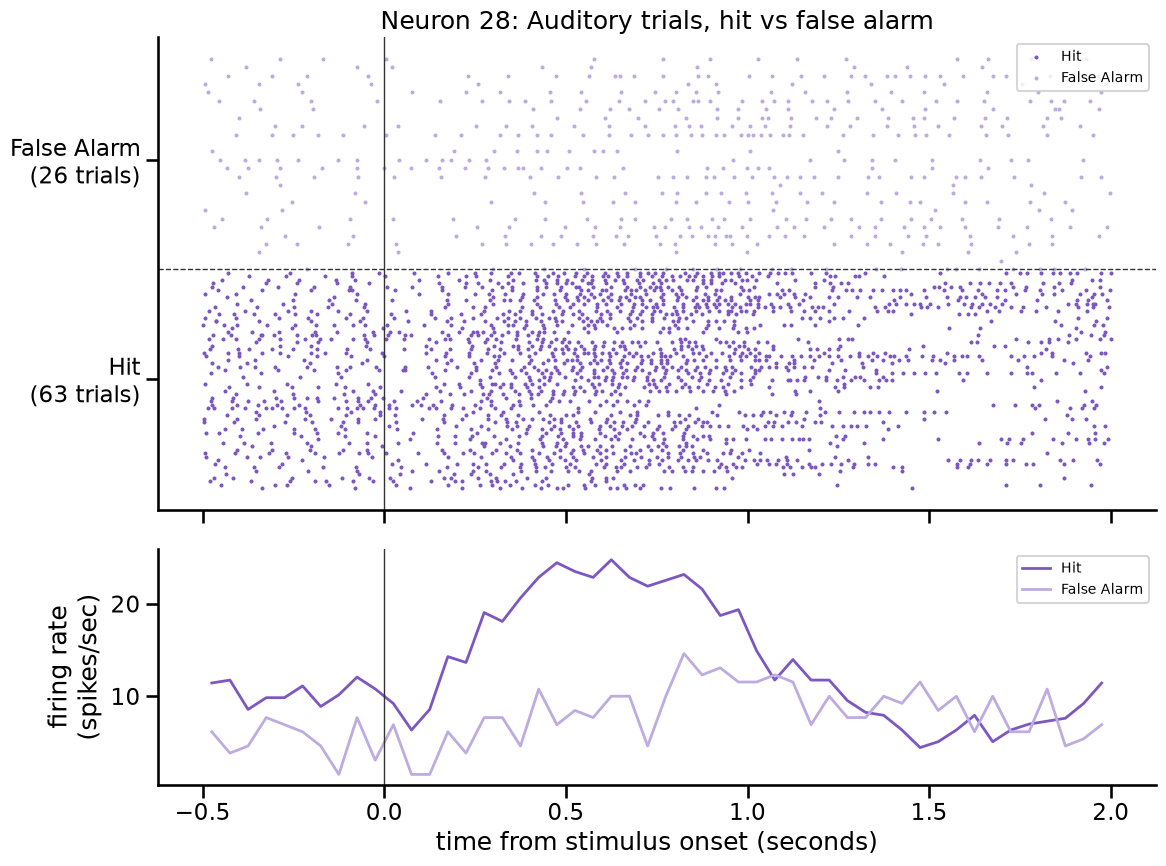

In [3]:
# ==== CELL 11 (updated): hit vs false alarm, split into a VISUAL plot and an AUDITORY plot ====

def plot_hit_vs_fa(modality_trials, modality_label, modality_color):
    """given trials already filtered to one modality, split into hit vs FA and plot combined lanes"""
    hit_subset = modality_trials[modality_trials.is_hit]
    fa_subset = modality_trials[modality_trials.is_false_alarm]

    print('%s: %d hit trials, %d false alarm trials' % (modality_label, len(hit_subset), len(fa_subset)))

    hit_spike_times, hit_trial_index = align_spikes_to_trials(spike_times, hit_subset, pre_window, post_window)
    fa_spike_times, fa_trial_index = align_spikes_to_trials(spike_times, fa_subset, pre_window, post_window)

    hit_color = modality_color
    fa_color = lighten_color(modality_color, amount=0.5)

    hit_count_array, _ = np.histogram(hit_spike_times, bins=bins)
    hit_rate_array = hit_count_array / len(hit_subset) / bin_size

    fa_count_array, _ = np.histogram(fa_spike_times, bins=bins)
    fa_rate_array = fa_count_array / len(fa_subset) / bin_size

    lane_height = 100
    hit_trial_index_scaled = (hit_trial_index / len(hit_subset)) * lane_height
    fa_trial_index_scaled = (fa_trial_index / len(fa_subset)) * lane_height + lane_height

    fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    ax_raster.scatter(hit_spike_times, hit_trial_index_scaled, s=2, c=hit_color, label='Hit')
    ax_raster.scatter(fa_spike_times, fa_trial_index_scaled, s=2, c=fa_color, label='False Alarm')
    ax_raster.axhline(lane_height, c=C_GREY, lw=1, ls='--')
    ax_raster.axvline(0, c=C_GREY, lw=1)
    ax_raster.set_yticks([lane_height / 2, lane_height + lane_height / 2])
    ax_raster.set_yticklabels(['Hit\n(%d trials)' % len(hit_subset), 'False Alarm\n(%d trials)' % len(fa_subset)])
    ax_raster.set_title('Neuron %d: %s trials, hit vs false alarm' % (neuron_id, modality_label))
    ax_raster.legend(loc='upper right', fontsize=10)

    ax_trace.plot(bin_centers, hit_rate_array, c=hit_color, lw=2, label='Hit')
    ax_trace.plot(bin_centers, fa_rate_array, c=fa_color, lw=2, label='False Alarm')
    ax_trace.axvline(0, c=C_GREY, lw=1)
    ax_trace.set_xlabel('time from stimulus onset (seconds)')
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=10)

    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()
    plt.show()


# -- visual trials: hit vs false alarm --
plot_hit_vs_fa(vis_trials, 'Visual', C_TEAL)

# -- auditory trials: hit vs false alarm --
plot_hit_vs_fa(aud_trials, 'Auditory', C_PURPLE)

In [4]:
# ==== imports & settings ====
import os
import glob
import numpy as np
import pandas as pd
import pynwb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_context('talk')
pd.set_option('display.max_columns', None)

C_TEAL   = "#48A69C"
C_ORANGE = "#E78C3B"
C_PURPLE = "#7D57C1"
C_GREY   = "#333333"

def lighten_color(hex_color, amount=0.5):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(rgb[i] + (1 - rgb[i]) * amount for i in range(3))


# ==== neuron table + mouse -> session lookup ====
target_neurons = pd.DataFrame([
    {"id": 105,  "structure": "MOs", "cluster_id": 116, "block": "auditory", "mouse_id": 708016},
    {"id": 1593, "structure": "MOs", "cluster_id": 474, "block": "auditory", "mouse_id": 664851},
    {"id": 106,  "structure": "MOs", "cluster_id": 113, "block": "auditory", "mouse_id": 664851},
    {"id": 962,  "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 74,   "structure": "MOs", "cluster_id": 78,  "block": "auditory", "mouse_id": 667252},
    {"id": 916,  "structure": "MOs", "cluster_id": 28,  "block": "auditory", "mouse_id": 667252},
    {"id": 1768, "structure": "MOs", "cluster_id": 481, "block": "visual",   "mouse_id": 715710},
    {"id": 2124, "structure": "MOs", "cluster_id": 857, "block": "visual",   "mouse_id": 715710},
    {"id": 23,   "structure": "MOs", "cluster_id": 23,  "block": "visual",   "mouse_id": 667252},
    {"id": 94,   "structure": "MOs", "cluster_id": 105, "block": "visual",   "mouse_id": 708016},
    {"id": 1631, "structure": "MOs", "cluster_id": 39,  "block": "visual",   "mouse_id": 743199},  # table said 723199 -- confirm
    {"id": 2777, "structure": "MOp", "cluster_id": 565, "block": "auditory", "mouse_id": 742903},
    {"id": 2918, "structure": "MOp", "cluster_id": 711, "block": "auditory", "mouse_id": 742903},
    {"id": 841,  "structure": "MOp", "cluster_id": 476, "block": "auditory", "mouse_id": 708016},
    {"id": 2693, "structure": "MOp", "cluster_id": 684, "block": "visual",   "mouse_id": 742903},
    {"id": 586,  "structure": "MOp", "cluster_id": 213, "block": "visual",   "mouse_id": 708016},
    {"id": 325,  "structure": "MOp", "cluster_id": 188, "block": "visual",   "mouse_id": 667252},
])

mouse_to_session = {
    708016: "708016_2024-04-29",
    664851: "664851_2023-11-16",
    667252: "667252_2023-09-28",
    715710: "715710_2024-07-16",
    742903: "742903_2024-10-23",
    743199: "743199_2024-12-05",
}
target_neurons["session_id"] = target_neurons["mouse_id"].map(mouse_to_session)

data_root = '/root/capsule/data/dynamicrouting_datacube'
output_root = '/root/capsule/results/psth_plots'   # change this to wherever you want the folders to land

MAX_ISI_VIOLATIONS_RATIO = 0.5
MAX_AMPLITUDE_CUTOFF = 0.1
MIN_PRESENCE_RATIO = 0.95

STIM_PRE = 1.5     # partner's spec: 1.5s quiescent
STIM_POST = 1.0    # partner's spec: 1.0s stim + response
BIN_SIZE = 0.05


# ==== helper functions ====

def load_session(session_id):
    match_list = glob.glob('%s/*/%s.nwb.zarr' % (data_root, session_id))
    if len(match_list) != 1:
        print('skipping %s -- expected 1 match, found %d' % (session_id, len(match_list)))
        return None, None
    session = pynwb.read_nwb(match_list[0])
    trials = session.trials.to_dataframe()
    units_table = session.units.to_dataframe()
    good_units = units_table[
        (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
        (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
        (units_table.presence_ratio > MIN_PRESENCE_RATIO)
    ]
    return trials, good_units


def align_spikes_to_events(spike_times, event_times, pre_window, post_window):
    triggered_spike_times = []
    triggered_trial_index = []
    for i, event_time in enumerate(event_times):
        mask = (spike_times >= event_time - pre_window) & (spike_times < event_time + post_window)
        trial_spikes = spike_times[mask] - event_time
        triggered_spike_times.append(trial_spikes)
        triggered_trial_index.append(np.ones(len(trial_spikes)) * i)
    return np.concatenate(triggered_spike_times), np.concatenate(triggered_trial_index)


def compute_lick_window(trials):
    """median stim->lick and lick->response-end durations, used to size the lick-aligned window"""
    responded = trials[trials["is_response"] & trials["response_time"].notna()]
    stim_to_lick = (responded["response_time"] - responded["stim_start_time"]).median()
    lick_to_resp_end = (responded["response_window_stop_time"] - responded["response_time"]).median()
    return stim_to_lick, lick_to_resp_end


def plot_pair(spike_times, group_a, label_a, color_a, group_b, label_b, color_b,
              align_column, pre_window, post_window, bin_size, title,
              orange_marker_time=None, orange_marker_label=None, save_path=None):
    """combined two-lane raster + overlaid trace for two trial groups, optional orange marker line"""
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size / 2
    lane_height = 100

    a_times = group_a[align_column].dropna().values
    b_times = group_b[align_column].dropna().values
    if len(a_times) == 0 or len(b_times) == 0:
        print('skipping "%s" -- one group has 0 trials (%s: %d, %s: %d)' %
              (title, label_a, len(a_times), label_b, len(b_times)))
        return

    a_spikes, a_index = align_spikes_to_events(spike_times, a_times, pre_window, post_window)
    b_spikes, b_index = align_spikes_to_events(spike_times, b_times, pre_window, post_window)

    a_rate, _ = np.histogram(a_spikes, bins=bins)
    a_rate = a_rate / len(a_times) / bin_size
    b_rate, _ = np.histogram(b_spikes, bins=bins)
    b_rate = b_rate / len(b_times) / bin_size

    a_index_scaled = (a_index / len(a_times)) * lane_height
    b_index_scaled = (b_index / len(b_times)) * lane_height + lane_height

    fig, (ax_raster, ax_trace) = plt.subplots(nrows=2, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    ax_raster.scatter(a_spikes, a_index_scaled, s=2, c=color_a, label=label_a)
    ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)
    ax_raster.axhline(lane_height, c=C_GREY, lw=1, ls='--')
    ax_raster.axvline(0, c=C_GREY, lw=1)
    if orange_marker_time is not None:
        ax_raster.axvline(orange_marker_time, c=C_ORANGE, lw=1.5, ls='--', label=orange_marker_label)
    ax_raster.set_yticks([lane_height / 2, lane_height + lane_height / 2])
    ax_raster.set_yticklabels(['%s\n(%d trials)' % (label_a, len(a_times)), '%s\n(%d trials)' % (label_b, len(b_times))])
    ax_raster.set_title(title)
    ax_raster.legend(loc='upper right', fontsize=9)

    ax_trace.plot(bin_centers, a_rate, c=color_a, lw=2, label=label_a)
    ax_trace.plot(bin_centers, b_rate, c=color_b, lw=2, label=label_b)
    ax_trace.axvline(0, c=C_GREY, lw=1)
    if orange_marker_time is not None:
        ax_trace.axvline(orange_marker_time, c=C_ORANGE, lw=1.5, ls='--', label=orange_marker_label)
    ax_trace.set_xlabel('time (seconds)')
    ax_trace.set_ylabel('firing rate\n(spikes/sec)')
    ax_trace.legend(loc='upper right', fontsize=9)

    for single_ax in [ax_raster, ax_trace]:
        sns.despine(ax=single_ax)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
        plt.close(fig)
        print('saved: %s' % save_path)
    else:
        plt.show()


# ==== main loop: every neuron in the table ====
session_cache = {}   # avoid reloading the same session multiple times

for _, row in target_neurons.iterrows():
    session_id = row.session_id
    if session_id is None or pd.isna(session_id):
        print('no known session for mouse %s (id %d) -- skipping' % (row.mouse_id, row.id))
        continue

    if session_id not in session_cache:
        session_cache[session_id] = load_session(session_id)
    trials, good_units = session_cache[session_id]
    if good_units is None:
        continue

    structure_units = good_units[good_units.structure == row.structure]
    match = structure_units[structure_units.cluster_id == row.cluster_id]
    if len(match) == 0:
        print('no match for id %d (cluster_id %d, %s) in session %s' % (row.id, row.cluster_id, row.structure, session_id))
        continue

    neuron_id = row.cluster_id
    spike_times = match.iloc[0].spike_times

    # ---- output folder: one subfolder per mouse ID ----
    mouse_folder = os.path.join(output_root, str(row.mouse_id))
    os.makedirs(mouse_folder, exist_ok=True)
    file_prefix = 'neuron%d_%s' % (neuron_id, row.structure)

    vis_trials = trials[trials.is_vis_stim]
    aud_trials = trials[trials.is_aud_stim]
    vis_hit = vis_trials[vis_trials.is_hit]
    vis_fa = vis_trials[vis_trials.is_false_alarm]
    aud_hit = aud_trials[aud_trials.is_hit]
    aud_fa = aud_trials[aud_trials.is_false_alarm]

    stim_to_lick, lick_to_resp_end = compute_lick_window(trials)
    print('neuron %d (mouse %s): median stim->lick = %.2fs, lick->response end = %.2fs' %
          (neuron_id, row.mouse_id, stim_to_lick, lick_to_resp_end))

    # ---- STIM-ALIGNED (-1.5s to +1.0s), orange line = median lick time ----
    plot_pair(spike_times, vis_trials, 'Visual', C_TEAL, aud_trials, 'Auditory', C_PURPLE,
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: visual vs auditory (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_vis_vs_aud_stimaligned.png' % file_prefix))

    plot_pair(spike_times, vis_hit, 'Hit', C_TEAL, vis_fa, 'False Alarm', lighten_color(C_TEAL, 0.5),
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: visual, hit vs false alarm (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_visual_hit_vs_fa_stimaligned.png' % file_prefix))

    plot_pair(spike_times, aud_hit, 'Hit', C_PURPLE, aud_fa, 'False Alarm', lighten_color(C_PURPLE, 0.5),
              'stim_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: auditory, hit vs false alarm (stim-aligned)' % neuron_id,
              orange_marker_time=stim_to_lick, orange_marker_label='median lick time',
              save_path=os.path.join(mouse_folder, '%s_auditory_hit_vs_fa_stimaligned.png' % file_prefix))

    # ---- LICK-ALIGNED (median stim->lick before, median lick->response-end after), orange line = median stim onset ----
    vis_trials_l = vis_trials[vis_trials["is_response"] & vis_trials["response_time"].notna()].copy()
    aud_trials_l = aud_trials[aud_trials["is_response"] & aud_trials["response_time"].notna()].copy()
    vis_hit_l = vis_trials_l[vis_trials_l.is_hit]
    vis_fa_l = vis_trials_l[vis_trials_l.is_false_alarm]
    aud_hit_l = aud_trials_l[aud_trials_l.is_hit]
    aud_fa_l = aud_trials_l[aud_trials_l.is_false_alarm]

    plot_pair(spike_times, vis_trials_l, 'Visual', C_TEAL, aud_trials_l, 'Auditory', C_PURPLE,
              'response_time', stim_to_lick, lick_to_resp_end, BIN_SIZE,
              'Neuron %d: visual vs auditory (lick-aligned)' % neuron_id,
              orange_marker_time=-stim_to_lick, orange_marker_label='median stim onset',
              save_path=os.path.join(mouse_folder, '%s_vis_vs_aud_lickaligned.png' % file_prefix))

    plot_pair(spike_times, vis_hit_l, 'Hit', C_TEAL, vis_fa_l, 'False Alarm', lighten_color(C_TEAL, 0.5),
              'response_time', stim_to_lick, lick_to_resp_end, BIN_SIZE,
              'Neuron %d: visual, hit vs false alarm (lick-aligned)' % neuron_id,
              orange_marker_time=-stim_to_lick, orange_marker_label='median stim onset',
              save_path=os.path.join(mouse_folder, '%s_visual_hit_vs_fa_lickaligned.png' % file_prefix))

    plot_pair(spike_times, aud_hit_l, 'Hit', C_PURPLE, aud_fa_l, 'False Alarm', lighten_color(C_PURPLE, 0.5),
              'response_time', stim_to_lick, lick_to_resp_end, BIN_SIZE,
              'Neuron %d: auditory, hit vs false alarm (lick-aligned)' % neuron_id,
              orange_marker_time=-stim_to_lick, orange_marker_label='median stim onset',
              save_path=os.path.join(mouse_folder, '%s_auditory_hit_vs_fa_lickaligned.png' % file_prefix))

    # ---- QUIESCENT-ALIGNED, visual vs auditory only (no hit/FA split -- outcome hasn't happened yet) ----
    plot_pair(spike_times, vis_trials, 'Visual', C_TEAL, aud_trials, 'Auditory', C_PURPLE,
              'quiescent_start_time', STIM_PRE, STIM_POST, BIN_SIZE,
              'Neuron %d: visual vs auditory (quiescent-aligned)' % neuron_id,
              save_path=os.path.join(mouse_folder, '%s_vis_vs_aud_quiescentaligned.png' % file_prefix))

print('done -- check %s for saved plots, organized by mouse ID folder' % output_root)

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (435944, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (435963, 500) float32 read-only>
  warnings.warn(


neuron 116 (mouse 708016): median stim->lick = 0.43s, lick->response end = 0.56s
saved: /root/capsule/results/psth_plots/708016/neuron116_MOs_vis_vs_aud_stimaligned.png


/tmp/ipykernel_34991/2287559920.py:133: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)


saved: /root/capsule/results/psth_plots/708016/neuron116_MOs_visual_hit_vs_fa_stimaligned.png


/tmp/ipykernel_34991/2287559920.py:133: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)


...

saved: /root/capsule/results/psth_plots/667252/neuron188_MOp_auditory_hit_vs_fa_stimaligned.png
saved: /root/capsule/results/psth_plots/667252/neuron188_MOp_vis_vs_aud_lickaligned.png


/tmp/ipykernel_34991/2287559920.py:133: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)


saved: /root/capsule/results/psth_plots/667252/neuron188_MOp_visual_hit_vs_fa_lickaligned.png


/tmp/ipykernel_34991/2287559920.py:133: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_raster.scatter(b_spikes, b_index_scaled, s=2, c=color_b, label=label_b)


saved: /root/capsule/results/psth_plots/667252/neuron188_MOp_auditory_hit_vs_fa_lickaligned.png
saved: /root/capsule/results/psth_plots/667252/neuron188_MOp_vis_vs_aud_quiescentaligned.png
done -- check /root/capsule/results/psth_plots for saved plots, organized by mouse ID folder
